# Surface wear from height matrices

TrueMapData wear-simulation notebook: height-matrix contact, sliding, and wear using TrueMapData inputs and exports.

Two rough height fields slide against each other, contact is found from local height interference,
traction is estimated from normal force and directional friction, wear energy is accumulated, then
material is removed from **both** height maps (master and slave), with optional **hardness** scaling so one body wears faster than the other. Cumulative **slave** wear and **slave-body** sliding distance roll with the moving surface for consistent visualization.

This notebook is set up as a clean CPU reference for the GPU texture-space wear project:

- **Surface data**: loads any `.tmd` or `.mat` (TrueMap **`MATExporter`** / `tmd_surface_v1` schema) via `INPUT_A` /
  `INPUT_B`. By default it auto-discovers `examples/gelsight/circle_0mm_100g_heightmap_linear_detrend.tmd`
  for the master and pairs it with a flat zero-height slave plane.
- **Contact**: supports both fixed-gap mode and load-controlled bisection.
- **Friction**: four directional coefficient maps, similar to the GPU `mu(+u)`, `mu(-u)`, `mu(+v)`,
  `mu(-v)` setup.
- **Wear stability**: clamps per-step wear and supports a top-k mode so contact never collapses in
  one step.
- **Visualization**: surface gallery, friction maps, contact dashboard, evolution grid with
  cumulative wear and per-step increment, removed-material map, cross-section, metric table, 2x2
  animated GIF, and surface-pair comparison.
- **Export**: canonical `.mat` with `Surface_simulation_i` keys under `notebooks/wear_results/` plus
  `final_state.npz`, `snapshots.npz`, CSV logs, `truemap_metadata.json`, `wear_evolution.gif`, and a high-detail OBJ mesh.

## References

Sun, D. (2025). *MATLAB code for 'Surface wear characterized by height matrix in relation to texture direction (Std) and other surface parameters'* (Version 1) [Computer software and data set]. *Mendeley Data*. https://doi.org/10.17632/v635kysfr2.1

Landing page: https://data.mendeley.com/datasets/v635kysfr2/1 (CC BY 4.0). Describes Greenwood-Williamson contact and Rabinowicz wear on height matrices; this notebook is a Python/Jupyter port aligned with that workflow and TrueMapData inputs.


## 1. Imports

In [ ]:
from __future__ import annotations

from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, Tuple, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  registers 3d projection
from scipy import io, ndimage

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.figsize": (7, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "image.cmap": "viridis",
})

np.set_printoptions(precision=5, suppress=True)

## 2. Parameters

`published_params` keeps the original MATLAB values. For the notebook visual demo, `demo_params` uses a smaller gap, a smaller wear scale, a tighter clamp, and a top-k wear update. This avoids the bad behavior in the earlier notebook where contact almost vanished after the first step.

All **session constants** (I/O paths, grid caps, surface indices, step counts, relative **hardness** of master vs slave, and default 3D plot offsets) live at the **top of the next code cell** so you can retune without hunting through the notebook. Higher `HARDNESS_SLAVE` makes the slave wear more slowly than the master for the same contact energy.

In [ ]:
@dataclass
class WearParameters:
    # Contact offset. In fixed-gap mode, lower h0 means less penetration.
    h0: float = 1.3

    # Material and contact constants from the MATLAB parameter file.
    E: float = 0.103
    poisson: float = 0.34
    f0: float = 0.075
    G: float = 0.041
    R: float = 0.5

    # Adhesive wear threshold.
    deltaw: float = 3.4e-12

    # Target normal force for load-controlled mode.
    normalF: float = 0.00359
    normal_error: float = 0.0001

    # Sliding distance per step.
    delta_slid: float = 1.0

    # Original MATLAB wear_depth.m uses a large multiplier.
    # That is too aggressive when we run a fixed-gap visual demo.
    wear_scale: float = 5000.0

    # Friction clamp used to avoid edge spikes.
    friction_clip: float = 0.3

    # Numerical safety for vectorized wear.
    enable_wear_clamp: bool = True
    wear_clamp_frac: float = 0.16

    # Wear update mode.
    # "all" wears all texels above the threshold.
    # "topk" wears only the highest-energy fraction each step, closer to the MATLAB greedy loop.
    wear_mode: str = "all"
    max_wear_fraction: float = 1.0

    # Solver controls.
    max_h0_iterations: int = 400

    # Relative hardness (higher = harder body = smaller wear depth for the same dissipated energy).
    hardness_master: float = 1.0
    hardness_slave: float = 1.0

    @property
    def Ex(self) -> float:
        return self.E / (1.0 - self.poisson**2)

    @property
    def Gx(self) -> float:
        return 4.0 * self.G / (2.0 - self.poisson)


# -----------------------------------------------------------------------------
# Session constants (edit here): indices, steps, hardness split, plot defaults
# -----------------------------------------------------------------------------
MS_IDX: int = 1
SS_IDX: int = 2
SLIDE_DIR: int = 1
LOAD_CONTROLLED: bool = False
N_STEPS: int = 200
SAVE_EVERY: int = 20

# Master vs slave hardness (Archard-style: wear depth ~ 1 / H).
HARDNESS_MASTER: float = 1.0
HARDNESS_SLAVE: float = 3.0

PLOT_PAIR_3D_H0: float = -2.0
PLOT_PAIR_3D_STRIDE: int = 8

# I/O and grid preprocessing (see markdown in the load section for semantics).
INPUT_A: "str | Path | None" = None
INPUT_B: "str | Path | None" = None
SECOND_SURFACE_MODE: str = "flat"
MAX_GRID_DIM: int = 256
NORMALIZE_TO_UNIT_SQ: bool = True

published_params = WearParameters()

demo_params = WearParameters(
    h0=-2.0,
    wear_scale=1.0,
    wear_clamp_frac=0.03,
    wear_mode="topk",
    max_wear_fraction=0.02,
    hardness_master=HARDNESS_MASTER,
    hardness_slave=HARDNESS_SLAVE,
)

pd.DataFrame({
    "published_params": asdict(published_params),
    "demo_params": asdict(demo_params),
})


,published_params,demo_params
h0,1.3,-2.0
E,0.103,0.103
poisson,0.34,0.34
f0,0.075,0.075
G,0.041,0.041
R,0.5,0.5
deltaw,0.0,0.0
normalF,0.00359,0.00359
normal_error,0.0001,0.0001
delta_slid,1.0,1.0


## 3. Load TrueMapData or MATLAB surfaces

Configure the inputs at the top of the next cell:

- `INPUT_A`: master height map source (`.tmd` or `.mat`). Leave `None` to auto-discover (TMD first, then MAT).
- `INPUT_B`: slave height map source (`.tmd` or `.mat`). Leave `None` to fall back to `SECOND_SURFACE_MODE`.
- `SECOND_SURFACE_MODE`: how to build the slave when `INPUT_B is None`. Choices:
  - `"flat"` (default): zero-height plane the same shape as the master.
  - `"mirror"`: master flipped through both axes (legacy single-TMD behavior).
  - `"same_file"`: use the second `Surface_simulation_*` array stored inside `INPUT_A` (legacy multi-surface MAT).

The negative-sign convention is unchanged:

```text
MS = surfaces[1]
SS = -surfaces[2]
```

The negative sign flips the slave so the two height maps face each other.


In [ ]:
from tmd.compression import MATImporter, MATExporter
from tmd import TMD


_TMD_SUFFIXES = {".tmd"}
_MAT_SUFFIXES = {".mat"}


def _maybe_downsample(arr: np.ndarray, max_dim: int) -> np.ndarray:
    arr = np.asarray(arr, dtype=np.float64)
    if max_dim is None or max_dim <= 0:
        return arr
    h, w = arr.shape
    longest = max(h, w)
    if longest <= max_dim:
        return arr
    factor = max_dim / float(longest)
    return ndimage.zoom(arr, zoom=factor, order=1).astype(np.float64)


def _maybe_normalize(arr: np.ndarray) -> tuple[np.ndarray, float]:
    """Subtract the mean and rescale to unit Sq so demo_params behaves the same regardless of input units."""
    arr = np.asarray(arr, dtype=np.float64)
    if not NORMALIZE_TO_UNIT_SQ:
        return arr, 1.0
    centered = arr - float(np.mean(arr))
    sq = float(np.sqrt(np.mean(centered ** 2)))
    if sq <= 1e-12:
        return centered, 1.0
    return centered / sq, sq


def _repo_root() -> Path:
    here = Path.cwd()
    if (here / "examples").is_dir() or (here / "tmd").is_dir():
        return here
    parent = here.parent
    if (parent / "examples").is_dir() or (parent / "tmd").is_dir():
        return parent
    return here


REPO_ROOT = _repo_root()
# All notebook exports default under the repo (portable; works from notebooks/ or repo root).
NOTEBOOK_EXPORT_ROOT = REPO_ROOT / "notebooks"
WEAR_RESULTS_DIR = NOTEBOOK_EXPORT_ROOT / "wear_results"
DERIVED_SURFACES_MAT = NOTEBOOK_EXPORT_ROOT / "derived_surfaces.mat"


def _coerce_to_metric_dict(raw: dict) -> Dict[str, float]:
    cleaned: Dict[str, float] = {}
    for name, value in raw.items():
        if name == "Zp":
            continue
        try:
            cleaned[name] = float(np.asarray(value).flatten()[0])
        except (TypeError, ValueError):
            cleaned[name] = value
    return cleaned


def _detect_kind(path: Path) -> str:
    suffix = path.suffix.lower()
    if suffix in _TMD_SUFFIXES:
        return "tmd"
    if suffix in _MAT_SUFFIXES:
        return "mat"
    raise ValueError(f"Unsupported input extension {suffix!r} for {path}")


def find_default_input():
    tmd_candidates = [
        REPO_ROOT / "examples/gelsight/circle_0mm_100g_heightmap_linear_detrend.tmd",
        Path("examples/gelsight/circle_0mm_100g_heightmap_linear_detrend.tmd"),
    ]
    for p in tmd_candidates:
        if p.exists():
            return "tmd", p

    mat_candidates = [
        NOTEBOOK_EXPORT_ROOT / "derived_surfaces.mat",
        Path("notebooks/derived_surfaces.mat"),
        Path("derived_surfaces.mat"),
    ]
    for p in mat_candidates:
        if p.exists():
            return "mat", p
    return None, None


def _surfaces_from_tmd(tmd_path: Path):
    obj = TMD.load(str(tmd_path))
    base = np.asarray(obj.height_map, dtype=np.float64)
    if base.ndim != 2:
        raise ValueError(f"Expected 2D height map in {tmd_path}, got shape={base.shape}")
    original_shape = base.shape
    base = _maybe_downsample(base, MAX_GRID_DIM)
    base, original_sq = _maybe_normalize(base)
    raw_meta = obj.metadata if isinstance(obj.metadata, dict) else dict(obj.metadata or {})
    metadata = {"source": str(tmd_path), "kind": "tmd"}
    for key in ("mmpp", "x_length", "y_length", "x_offset", "y_offset"):
        if key in raw_meta:
            try:
                metadata[key] = float(raw_meta[key])
            except (TypeError, ValueError):
                metadata[key] = raw_meta[key]
    if base.shape != original_shape:
        metadata["downsampled_from"] = f"{original_shape[0]}x{original_shape[1]}"
        metadata["downsampled_to"] = f"{base.shape[0]}x{base.shape[1]}"
    if NORMALIZE_TO_UNIT_SQ:
        metadata["original_sq"] = original_sq
    surfaces = {1: base.copy()}
    stored_params = {1: {"source": "tmd", "path": str(tmd_path)}}
    return surfaces, stored_params, metadata


def _surfaces_from_mat(mat_path: Path):
    payload = MATImporter().load(str(mat_path))
    raw_surfaces = payload.get("surfaces") or {}
    surfaces: Dict[int, np.ndarray] = {}
    downsample_info: Dict[int, str] = {}
    sq_info: Dict[int, float] = {}
    for i, arr in raw_surfaces.items():
        original = np.asarray(arr, dtype=np.float64)
        downsampled = _maybe_downsample(original, MAX_GRID_DIM)
        if downsampled.shape != original.shape:
            downsample_info[int(i)] = f"{original.shape[0]}x{original.shape[1]}->{downsampled.shape[0]}x{downsampled.shape[1]}"
        normalized, original_sq = _maybe_normalize(downsampled)
        surfaces[int(i)] = normalized
        if NORMALIZE_TO_UNIT_SQ and abs(original_sq - 1.0) > 1e-3:
            sq_info[int(i)] = original_sq
    if not surfaces:
        raise KeyError(f"No Surface_simulation_* arrays found in {mat_path}")
    raw_params = payload.get("parameters", {}) or {}
    stored_params: Dict[int, dict] = {}
    for i, params in raw_params.items():
        cleaned = _coerce_to_metric_dict(dict(params))
        if cleaned:
            stored_params[int(i)] = cleaned
    raw_meta = payload.get("metadata") or {}
    metadata = {"source": str(mat_path), "kind": "mat"}
    if isinstance(raw_meta, dict):
        for key, value in raw_meta.items():
            try:
                metadata[key] = float(value)
            except (TypeError, ValueError):
                metadata[key] = value
    if "tmd_format" in payload:
        metadata["tmd_format"] = payload["tmd_format"]
    if "tmd_version" in payload:
        metadata["tmd_version"] = payload["tmd_version"]
    if downsample_info:
        metadata["downsampled"] = downsample_info
    if sq_info:
        metadata["original_sq"] = sq_info
    return surfaces, stored_params, metadata


def _load_one(path: Path):
    kind = _detect_kind(path)
    if kind == "tmd":
        return _surfaces_from_tmd(path)
    return _surfaces_from_mat(path)


def build_surfaces(input_a, input_b, second_mode):
    if input_a is None:
        kind, found = find_default_input()
        if found is None:
            raise FileNotFoundError(
                "No input found. Set INPUT_A to a .tmd or .mat path, or place a default file next to the notebook."
            )
        input_a = found
        a_kind = kind
    else:
        input_a = Path(input_a)
        a_kind = _detect_kind(input_a)

    surfaces_a, params_a, meta_a = _load_one(Path(input_a))
    a_first = min(surfaces_a)
    base = surfaces_a[a_first]

    surfaces: Dict[int, np.ndarray] = {1: base.copy()}
    stored_params: Dict[int, dict] = {}
    if a_first in params_a:
        stored_params[1] = dict(params_a[a_first])

    metadata = {
        "input_a": str(input_a),
        "input_a_kind": a_kind,
        "second_surface_mode": second_mode,
    }
    for key, value in meta_a.items():
        if key not in {"source", "kind"}:
            metadata[f"a_{key}"] = value

    if input_b is not None:
        input_b = Path(input_b)
        b_kind = _detect_kind(input_b)
        surfaces_b, params_b, meta_b = _load_one(input_b)
        b_first = min(surfaces_b)
        b_base = surfaces_b[b_first]
        if b_base.shape != base.shape:
            raise ValueError(
                f"Slave surface shape {b_base.shape} from {input_b} must match master shape {base.shape}"
            )
        surfaces[2] = b_base.copy()
        if b_first in params_b:
            stored_params[2] = dict(params_b[b_first])
        metadata["input_b"] = str(input_b)
        metadata["input_b_kind"] = b_kind
        for key, value in meta_b.items():
            if key not in {"source", "kind"}:
                metadata[f"b_{key}"] = value
        return surfaces, stored_params, metadata, "two_files"

    mode = (second_mode or "flat").lower()
    if mode == "flat":
        surfaces[2] = np.zeros_like(base, dtype=np.float64)
        stored_params[2] = {"source": "flat"}
        metadata["slave"] = "flat_zero"
        return surfaces, stored_params, metadata, "flat"
    if mode == "mirror":
        surfaces[2] = np.flipud(np.fliplr(base)).copy()
        stored_params[2] = {"source": f"{a_kind}_mirrored"}
        metadata["slave"] = "mirror"
        return surfaces, stored_params, metadata, "mirror"
    if mode == "same_file":
        for idx, arr in surfaces_a.items():
            if int(idx) == a_first:
                continue
            new_idx = int(idx) if int(idx) != 1 else max(surfaces) + 1
            surfaces[new_idx] = arr.copy()
            if int(idx) in params_a:
                stored_params[new_idx] = dict(params_a[int(idx)])
        if 2 not in surfaces:
            raise ValueError(
                f"SECOND_SURFACE_MODE='same_file' requires INPUT_A to contain >=2 surfaces; found {len(surfaces_a)}."
            )
        metadata["slave"] = "same_file"
        return surfaces, stored_params, metadata, "same_file"

    raise ValueError(
        f"Unknown SECOND_SURFACE_MODE={second_mode!r}; expected one of 'flat', 'mirror', 'same_file'"
    )


def select_pair(surfaces: Dict[int, np.ndarray], ms_idx: int, ss_idx: int):
    return surfaces[ms_idx].copy(), -surfaces[ss_idx].copy()


surfaces, stored_surface_params, truemap_metadata, _resolved_mode = build_surfaces(
    INPUT_A, INPUT_B, SECOND_SURFACE_MODE
)
input_path = Path(truemap_metadata["input_a"])
input_kind = truemap_metadata["input_a_kind"]
mat_path = input_path

print(f"Loaded {len(surfaces)} surfaces, mode={_resolved_mode}")
print(f"  master from: {input_path} ({input_kind})")
if "input_b" in truemap_metadata:
    print(f"  slave  from: {truemap_metadata['input_b']} ({truemap_metadata['input_b_kind']})")
else:
    print(f"  slave  : {truemap_metadata.get('slave', 'n/a')}")
print("Shape:", next(iter(surfaces.values())).shape)

if truemap_metadata:
    display(pd.Series(truemap_metadata, name="value").to_frame())

pd.DataFrame(stored_surface_params).T.round(5)


Loaded 2 surfaces, mode=flat
  master from: E:\TrueMapData\examples\gelsight\circle_0mm_100g_heightmap_linear_detrend.tmd (tmd)
  slave  : flat_zero
Shape: (171, 256)


,value
input_a,E:\TrueMapData\examples\gelsight\circle_0mm_10...
input_a_kind,tmd
second_surface_mode,flat
a_mmpp,0.001274
a_x_length,7.675058
a_y_length,5.12435
a_x_offset,0.0
a_y_offset,0.0
a_downsampled_from,4022x6024
a_downsampled_to,171x256


,source,path
1,tmd,E:\TrueMapData\examples\gelsight\circle_0mm_10...
2,flat,NaN


## 4. Visualization helpers

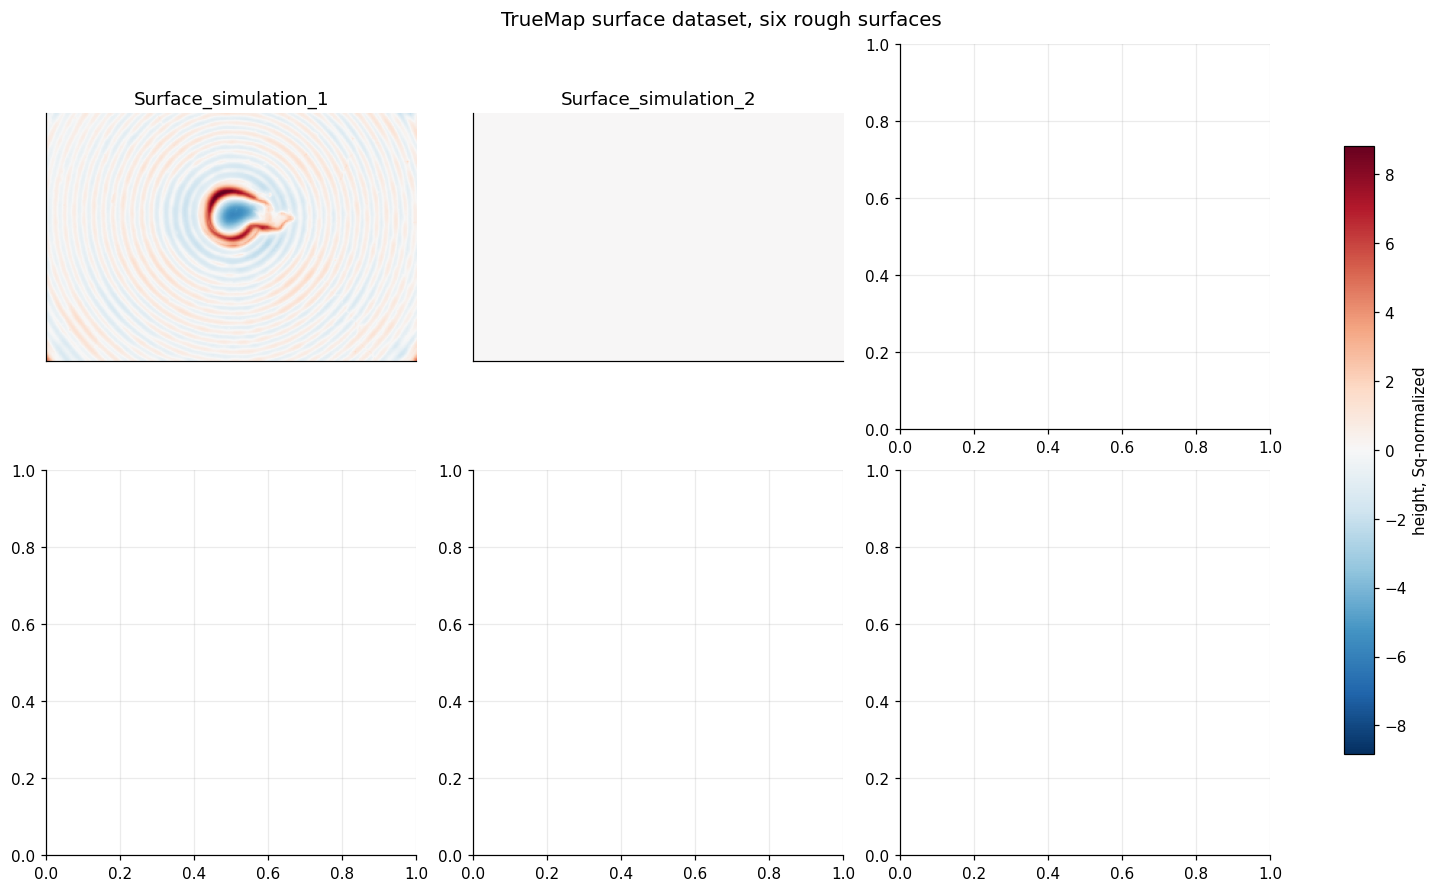

In [ ]:
def imshow_field(ax, Z, title: str, cmap: str = "viridis", vmin=None, vmax=None, cbar=True):
    im = ax.imshow(Z, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    if cbar:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return im


def robust_limits(arrays, q=(1, 99)):
    x = np.concatenate([np.asarray(a).ravel() for a in arrays])
    x = x[np.isfinite(x)]
    if x.size == 0:
        return 0.0, 1.0
    lo, hi = np.percentile(x, q)
    if np.isclose(lo, hi):
        hi = lo + 1e-12
    return float(lo), float(hi)


def plot_surface_gallery(surfaces: Dict[int, np.ndarray]):
    vmax = max(float(np.max(np.abs(Z))) for Z in surfaces.values())
    fig, axes = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)
    for ax, (idx, Z) in zip(axes.flat, surfaces.items()):
        im = imshow_field(ax, Z, f"Surface_simulation_{idx}", cmap="RdBu_r", vmin=-vmax, vmax=vmax, cbar=False)
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.75, label="height, Sq-normalized")
    fig.suptitle("TrueMap surface dataset, six rough surfaces", fontsize=13)
    plt.show()


plot_surface_gallery(surfaces)

## 5. Select a surface pair

MS = Surface_1, SS = -Surface_2, sliding = +x
MS range: -5.765 to +8.826
SS range: -0.000 to -0.000


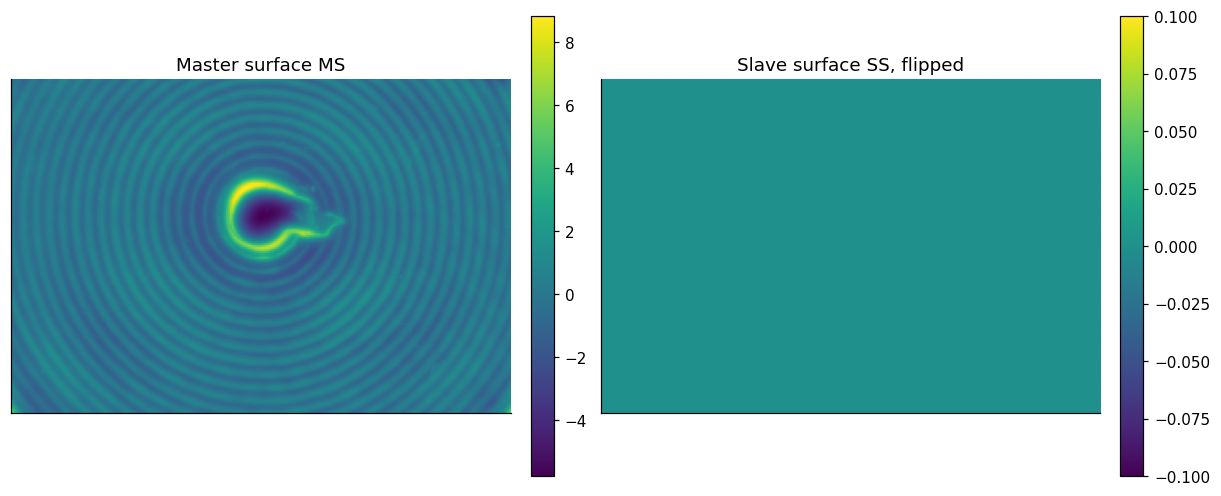

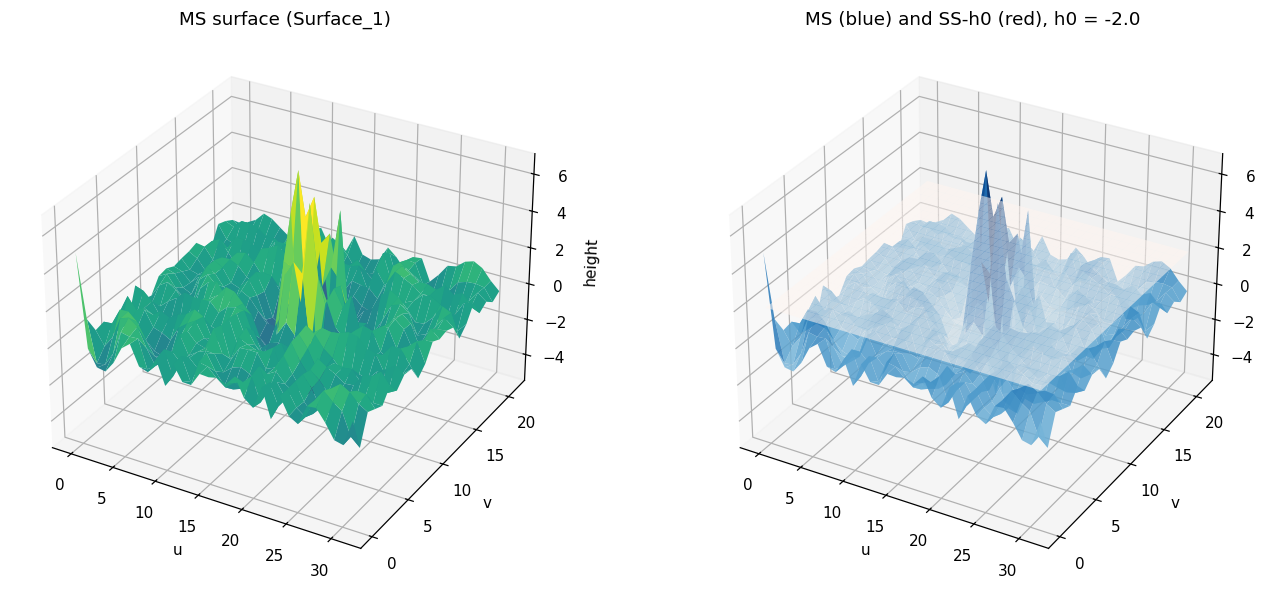

In [ ]:
DIRECTION_NAMES = {1: "+x", 2: "-x", 3: "+y", 4: "-y"}

MS0, SS0 = select_pair(surfaces, MS_IDX, SS_IDX)
print(f"MS = Surface_{MS_IDX}, SS = -Surface_{SS_IDX}, sliding = {DIRECTION_NAMES[SLIDE_DIR]}")
print(f"MS range: {MS0.min():+.3f} to {MS0.max():+.3f}")
print(f"SS range: {SS0.min():+.3f} to {SS0.max():+.3f}")

# 2D heatmaps of the chosen pair
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
imshow_field(axes[0], MS0, "Master surface MS")
imshow_field(axes[1], SS0, "Slave surface SS, flipped")
plt.show()


# 3D view of the same pair, with SS lifted by an indicative h0 so the gap is visible
def plot_pair_3d(MS, SS, h0_demo=None, stride=None):
    if h0_demo is None:
        h0_demo = PLOT_PAIR_3D_H0
    if stride is None:
        stride = PLOT_PAIR_3D_STRIDE
    fig = plt.figure(figsize=(13, 5.5))

    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    sub = MS[::stride, ::stride]
    yy, xx = np.meshgrid(np.arange(sub.shape[0]), np.arange(sub.shape[1]), indexing="ij")
    ax1.plot_surface(xx, yy, sub, cmap="viridis", linewidth=0, antialiased=True)
    ax1.set_title(f"MS surface (Surface_{MS_IDX})")
    ax1.set_xlabel("u"); ax1.set_ylabel("v"); ax1.set_zlabel("height")

    ax2 = fig.add_subplot(1, 2, 2, projection="3d")
    ax2.plot_surface(xx, yy, MS[::stride, ::stride], cmap="Blues",
                     linewidth=0, antialiased=True, alpha=0.85)
    sub_ss = SS[::stride, ::stride] - h0_demo
    ax2.plot_surface(xx, yy, sub_ss, cmap="Reds",
                     linewidth=0, antialiased=True, alpha=0.55)
    ax2.set_title(f"MS (blue) and SS-h0 (red), h0 = {h0_demo}")
    ax2.set_xlabel("u"); ax2.set_ylabel("v"); ax2.set_zlabel("height")

    plt.tight_layout()
    plt.show()


plot_pair_3d(MS0, SS0)


## 6. Directional friction maps

This is the vectorized equivalent of `COF.m`. The friction is clipped to a non-negative range. This is safer for the Python notebook because negative `mu` would create negative traction and negative wear energy.

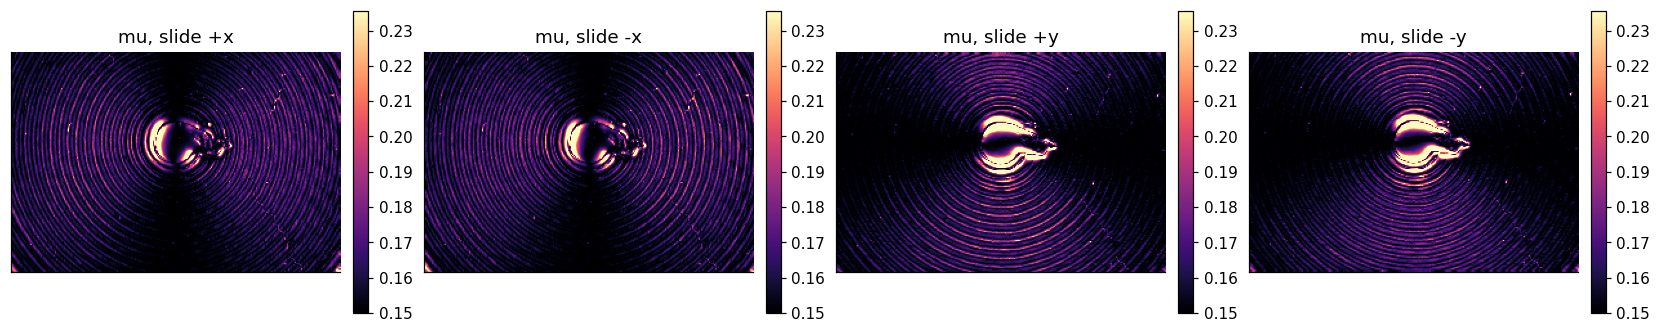

In [ ]:
def directional_slope(Z: np.ndarray, direction: int, spacing: float = 1.0) -> np.ndarray:
    Z = np.asarray(Z, dtype=np.float64)
    s = np.empty_like(Z)
    if direction == 1:
        s[:, :-1] = (Z[:, :-1] - Z[:, 1:]) / spacing
        s[:, -1] = s[:, -2]
    elif direction == 2:
        s[:, 1:] = (Z[:, 1:] - Z[:, :-1]) / spacing
        s[:, 0] = s[:, 1]
    elif direction == 3:
        s[:-1, :] = (Z[:-1, :] - Z[1:, :]) / spacing
        s[-1, :] = s[-2, :]
    elif direction == 4:
        s[1:, :] = (Z[1:, :] - Z[:-1, :]) / spacing
        s[0, :] = s[1, :]
    else:
        raise ValueError(f"direction must be one of {list(DIRECTION_NAMES)}")
    return s


def directional_mu(Z: np.ndarray, p: WearParameters, direction: int, spacing: float = 1.0) -> np.ndarray:
    slope = directional_slope(Z, direction, spacing)
    denom = np.sqrt(1.0 + slope * slope)
    sin_theta = slope / denom
    cos_theta = 1.0 / denom

    normal_component = p.normalF * cos_theta + p.normalF * p.f0 * sin_theta
    shear_component = p.normalF * p.f0 * cos_theta - p.normalF * sin_theta
    tau0 = np.divide(
        shear_component,
        normal_component,
        out=np.zeros_like(shear_component),
        where=np.abs(normal_component) > 1e-15,
    )
    return tau0 + slope


def combined_mu(MS: np.ndarray, SS: np.ndarray, p: WearParameters, direction: int) -> np.ndarray:
    raw = directional_mu(MS, p, direction) + directional_mu(SS, p, direction)
    return np.clip(raw, 0.0, p.friction_clip)


fig, axes = plt.subplots(1, 4, figsize=(15, 4), constrained_layout=True)
mu_maps = {d: combined_mu(MS0, SS0, demo_params, d) for d in (1, 2, 3, 4)}
mu_vmin, mu_vmax = robust_limits(mu_maps.values(), q=(0, 99))
for ax, d in zip(axes, (1, 2, 3, 4)):
    imshow_field(ax, mu_maps[d], f"mu, slide {DIRECTION_NAMES[d]}", cmap="magma", vmin=mu_vmin, vmax=mu_vmax)
plt.show()

## 7. Contact model

Local penetration is:

```text
d = MS - (SS - h0)
```

A texel is in contact when `d > 0`. The normal force uses the same Hertz-like form as the MATLAB code:

```text
dF = 4/3 * E* * sqrt(R) * d^(3/2)
```

In [ ]:
def contact_at_h0(MS: np.ndarray, SS: np.ndarray, h0: float, p: WearParameters, mu: np.ndarray) -> dict:
    d = MS - (SS - h0)
    mask = d > 0.0

    deltaF = np.zeros_like(MS, dtype=np.float64)
    deltaA = np.zeros_like(MS, dtype=np.float64)

    pen = d[mask]
    deltaF[mask] = (4.0 / 3.0) * p.Ex * np.sqrt(p.R) * np.power(pen, 1.5)
    deltaA[mask] = np.pi * p.R * pen

    tau = mu * deltaF
    ux = np.pi * (2.0 - p.poisson) * tau * p.R / (4.0 * p.G)

    return {
        "h0": float(h0),
        "d": d,
        "mask": mask,
        "deltaF": deltaF,
        "deltaA": deltaA,
        "tau": tau,
        "ux": ux,
        "N": int(mask.sum()),
        "area": float(deltaA.sum()),
        "force": float(deltaF.sum()),
    }


def solve_h0_for_load(MS: np.ndarray, SS: np.ndarray, p: WearParameters, mu: np.ndarray) -> dict:
    target = float(p.normalF)
    tolerance = max(abs(target * p.normal_error), 1e-18)

    extent = float(np.max(np.abs(MS)) + np.max(np.abs(SS)) + abs(p.h0) + 1.0)
    lo, hi = -extent, extent
    best = None

    for _ in range(p.max_h0_iterations):
        mid = 0.5 * (lo + hi)
        c = contact_at_h0(MS, SS, mid, p, mu)
        best = c
        if abs(c["force"] - target) <= tolerance:
            return c
        if c["force"] < target:
            lo = mid
        else:
            hi = mid
    return best


def compute_contact(MS: np.ndarray, SS: np.ndarray, p: WearParameters, direction: int, load_controlled: bool) -> dict:
    mu = combined_mu(MS, SS, p, direction)
    if load_controlled:
        return solve_h0_for_load(MS, SS, p, mu)
    return contact_at_h0(MS, SS, p.h0, p, mu)


contact0 = compute_contact(MS0, SS0, demo_params, SLIDE_DIR, LOAD_CONTROLLED)
print(f"Mode: {'load-controlled' if LOAD_CONTROLLED else 'fixed-gap'}")
print(f"h0: {contact0['h0']:.4f}")
print(f"Contact texels: {contact0['N']} / {MS0.size} = {100 * contact0['N'] / MS0.size:.2f}%")
print(f"Total normal force: {contact0['force']:.4e}")
print(f"Max traction: {contact0['tau'].max():.4e}")

Mode: fixed-gap
h0: -2.0000
Contact texels: 872 / 43776 = 1.99%
Total normal force: 4.2788e+02
Max traction: 5.1898e-01


## 8. Contact dashboard

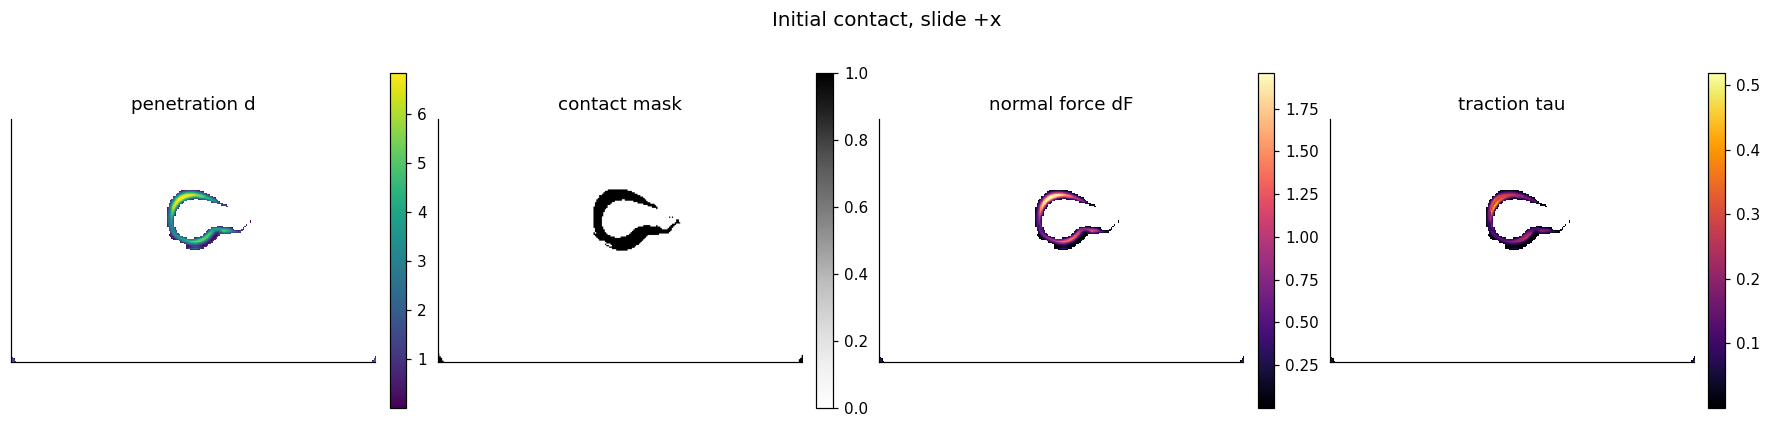

In [ ]:
def plot_contact_dashboard(c: dict, title: str = "Contact dashboard"):
    fields = [
        (np.where(c["mask"], c["d"], np.nan), "penetration d", "viridis"),
        (c["mask"].astype(float), "contact mask", "Greys"),
        (np.where(c["mask"], c["deltaF"], np.nan), "normal force dF", "magma"),
        (np.where(c["mask"], c["tau"], np.nan), "traction tau", "inferno"),
    ]
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)
    for ax, (Z, label, cmap) in zip(axes, fields):
        imshow_field(ax, Z, label, cmap=cmap)
    fig.suptitle(title, fontsize=13)
    plt.show()


plot_contact_dashboard(contact0, title=f"Initial contact, slide {DIRECTION_NAMES[SLIDE_DIR]}")

## 9. Wear update and sliding

Two fixes are important here:

1. The visual demo does not use the original `wear_scale=5000`, because that scale is calibrated for tiny load-controlled forces and crushes a fixed-gap simulation.
2. The demo uses `wear_mode='topk'`, so each step removes material from only the strongest energy texels. This is closer to the original MATLAB greedy update than a fully vectorized remove-everything-at-once update.

In [ ]:
def slip_energy(tau: np.ndarray, ux: np.ndarray) -> np.ndarray:
    return 0.5 * tau * ux


def sliding_energy(tau: np.ndarray, delta_slid: float) -> np.ndarray:
    return tau * delta_slid


def combined_wear_energy(contact: dict, p: WearParameters) -> np.ndarray:
    return slip_energy(contact["tau"], contact["ux"]) + sliding_energy(contact["tau"], p.delta_slid)


def select_wear_mask(energy: np.ndarray, p: WearParameters) -> np.ndarray:
    candidates = np.flatnonzero(energy.ravel() > p.deltaw)
    mask = np.zeros(energy.size, dtype=bool)
    if candidates.size == 0:
        return mask.reshape(energy.shape)
    if p.wear_mode == "topk":
        k = max(1, int(np.ceil(p.max_wear_fraction * candidates.size)))
        values = energy.ravel()[candidates]
        chosen = candidates[np.argpartition(values, -k)[-k:]]
        mask[chosen] = True
    elif p.wear_mode == "all":
        mask[candidates] = True
    else:
        raise ValueError("wear_mode must be 'all' or 'topk'")
    return mask.reshape(energy.shape)


def wear_depth_from_energy(
    energy: np.ndarray,
    Z: np.ndarray,
    p: WearParameters,
    inv_hardness: float = 1.0,
) -> np.ndarray:
    h = energy * p.wear_scale * inv_hardness
    if p.enable_wear_clamp:
        amp = float(Z.max() - Z.min())
        if amp > 0:
            h = np.minimum(h, p.wear_clamp_frac * amp)
    return h


def roll_with_slide(field: np.ndarray, direction: int) -> np.ndarray:
    shifts = {1: (0, 1), 2: (0, -1), 3: (1, 0), 4: (-1, 0)}
    return np.roll(field, shifts[direction], axis=(0, 1))


def apply_wear(MS: np.ndarray, SS: np.ndarray, eMS: np.ndarray, eSS: np.ndarray, p: WearParameters):
    MS = MS.copy()
    SS = SS.copy()
    eMS = eMS.copy()
    eSS = eSS.copy()

    maskMS = select_wear_mask(eMS, p)
    maskSS = select_wear_mask(eSS, p)

    inv_hm = 1.0 / max(float(p.hardness_master), 1e-12)
    inv_hs = 1.0 / max(float(p.hardness_slave), 1e-12)

    hMS = np.zeros_like(eMS)
    hSS = np.zeros_like(eSS)
    hMS[maskMS] = wear_depth_from_energy(eMS[maskMS], MS, p, inv_hm)
    hSS[maskSS] = wear_depth_from_energy(eSS[maskSS], SS, p, inv_hs)

    MS[maskMS] -= hMS[maskMS]
    SS[maskSS] += hSS[maskSS]

    eMS[maskMS] = 0.0
    eSS[maskSS] = 0.0

    info = {
        "wear_points_MS": int(maskMS.sum()),
        "wear_points_SS": int(maskSS.sum()),
        "wear_volume_MS": float(hMS.sum()),
        "wear_volume_SS": float(hSS.sum()),
        "max_wear_MS": float(hMS.max() if maskMS.any() else 0.0),
        "max_wear_SS": float(hSS.max() if maskSS.any() else 0.0),
    }
    return MS, SS, eMS, eSS, hMS, hSS, info


def slide_slave(SS: np.ndarray, eSS: np.ndarray, direction: int) -> Tuple[np.ndarray, np.ndarray]:
    return roll_with_slide(SS, direction), roll_with_slide(eSS, direction)


def sliding_vector(direction: int) -> Tuple[int, int]:
    return {1: (1, 0), 2: (-1, 0), 3: (0, 1), 4: (0, -1)}[direction]


## 10. Simulation loop

In [ ]:
def initialize_state(MS: np.ndarray, SS: np.ndarray, p: WearParameters, direction: int, load_controlled: bool) -> dict:
    contact = compute_contact(MS, SS, p, direction, load_controlled)
    e0 = combined_wear_energy(contact, p)
    slip0 = np.where(contact["mask"], p.delta_slid, 0.0)
    return {
        "MS": MS.copy(),
        "SS": SS.copy(),
        "wear_energy_MS": e0.copy(),
        "wear_energy_SS": e0.copy(),
        "cumulative_wear_MS": np.zeros_like(MS, dtype=np.float64),
        "cumulative_wear_SS": np.zeros_like(SS, dtype=np.float64),
        "last_wear_MS": np.zeros_like(MS, dtype=np.float64),
        "last_wear_SS": np.zeros_like(SS, dtype=np.float64),
        "sliding_distance": slip0.copy(),
        "sliding_distance_slave": slip0.copy(),
        "slide_u": np.full_like(MS, sliding_vector(direction)[0], dtype=np.float64),
        "slide_v": np.full_like(MS, sliding_vector(direction)[1], dtype=np.float64),
        "contact": contact,
    }


def simulation_step(state: dict, p: WearParameters, direction: int, load_controlled: bool) -> Tuple[dict, dict]:
    MS, SS = state["MS"], state["SS"]
    eMS, eSS = state["wear_energy_MS"], state["wear_energy_SS"]
    cumulative_wear_MS = state["cumulative_wear_MS"]
    cumulative_wear_SS = state["cumulative_wear_SS"]
    sliding_distance_slave = state["sliding_distance_slave"]

    MS, SS, eMS, eSS, hMS, hSS, wear_info = apply_wear(MS, SS, eMS, eSS, p)
    cumulative_wear_MS = cumulative_wear_MS + hMS
    cumulative_wear_SS = cumulative_wear_SS + hSS

    SS, eSS = slide_slave(SS, eSS, direction)
    cumulative_wear_SS = roll_with_slide(cumulative_wear_SS, direction)
    sliding_distance_slave = roll_with_slide(sliding_distance_slave, direction)

    contact = compute_contact(MS, SS, p, direction, load_controlled)
    new_energy = combined_wear_energy(contact, p)
    eMS = eMS + new_energy
    eSS = eSS + new_energy

    du, dv = sliding_vector(direction)
    slip_inc = np.where(contact["mask"], p.delta_slid, 0.0)
    sliding_distance = state["sliding_distance"] + slip_inc
    sliding_distance_slave = sliding_distance_slave + slip_inc

    new_state = {
        "MS": MS,
        "SS": SS,
        "wear_energy_MS": eMS,
        "wear_energy_SS": eSS,
        "cumulative_wear_MS": cumulative_wear_MS,
        "cumulative_wear_SS": cumulative_wear_SS,
        "last_wear_MS": hMS,
        "last_wear_SS": hSS,
        "sliding_distance": sliding_distance,
        "sliding_distance_slave": sliding_distance_slave,
        "slide_u": np.full_like(MS, du, dtype=np.float64),
        "slide_v": np.full_like(MS, dv, dtype=np.float64),
        "contact": contact,
    }

    log = {
        **wear_info,
        "h0": contact["h0"],
        "contact_texels": contact["N"],
        "contact_percent": 100.0 * contact["N"] / MS.size,
        "normal_force": contact["force"],
        "contact_area": contact["area"],
        "traction_sum": float(contact["tau"].sum()),
        "traction_max": float(contact["tau"].max()),
        "energy_max_MS": float(eMS.max()),
        "energy_sum_MS": float(eMS.sum()),
        "sliding_distance_sum": float(sliding_distance.sum()),
        "sliding_slave_sum": float(sliding_distance_slave.sum()),
        "cumulative_wear_sum_MS": float(cumulative_wear_MS.sum()),
        "cumulative_wear_sum_SS": float(cumulative_wear_SS.sum()),
        "cumulative_wear_max_MS": float(cumulative_wear_MS.max()),
        "cumulative_wear_max_SS": float(cumulative_wear_SS.max()),
    }
    return new_state, log


def make_snapshot(state: dict) -> dict:
    c = state["contact"]
    return {
        "MS": state["MS"].copy(),
        "SS": state["SS"].copy(),
        "mask": c["mask"].astype(float).copy(),
        "penetration": np.where(c["mask"], c["d"], 0.0).copy(),
        "tau": c["tau"].copy(),
        "wear_energy": state["wear_energy_MS"].copy(),
        "wear_map": state["cumulative_wear_MS"].copy(),
        "wear_map_SS": state["cumulative_wear_SS"].copy(),
        "wear_increment": state["last_wear_MS"].copy(),
        "wear_increment_SS": state["last_wear_SS"].copy(),
        "sliding_distance": state["sliding_distance"].copy(),
        "sliding_distance_slave": state["sliding_distance_slave"].copy(),
    }


def run_simulation(MS: np.ndarray, SS: np.ndarray, p: WearParameters, direction: int = 1, n_steps: int = 200, load_controlled: bool = False, save_every: int = 20):
    state = initialize_state(MS, SS, p, direction, load_controlled)
    logs: List[dict] = []
    snapshots = {0: make_snapshot(state)}

    for step_idx in range(1, n_steps + 1):
        state, log = simulation_step(state, p, direction, load_controlled)
        log["step"] = step_idx
        logs.append(log)
        if save_every and (step_idx % save_every == 0 or step_idx == n_steps):
            snapshots[step_idx] = make_snapshot(state)

    log_df = pd.DataFrame(logs).set_index("step")
    return state, log_df, snapshots


final_state, log, snapshots = run_simulation(
    MS0, SS0, demo_params,
    direction=SLIDE_DIR,
    n_steps=N_STEPS,
    load_controlled=LOAD_CONTROLLED,
    save_every=SAVE_EVERY,
)

print(f"Ran {N_STEPS} steps and saved {len(snapshots)} snapshots")
log[["contact_percent", "normal_force", "wear_volume_MS", "wear_volume_SS", "cumulative_wear_sum_MS", "cumulative_wear_sum_SS", "energy_max_MS"]].head()


Ran 200 steps and saved 11 snapshots


,contact_percent,normal_force,wear_volume_MS,cumulative_wear_sum_MS,energy_max_MS
step,,,,,
1,1.991959,415.430678,7.879005,7.879005,3.070923
2,1.982822,414.128301,7.879005,15.758010,4.479915
3,1.975969,413.170745,7.879005,23.637014,3.831996
4,1.982822,410.996965,7.834386,31.471400,5.450943
5,1.982822,408.412602,7.654224,39.125624,4.584376


## 11. Diagnostics

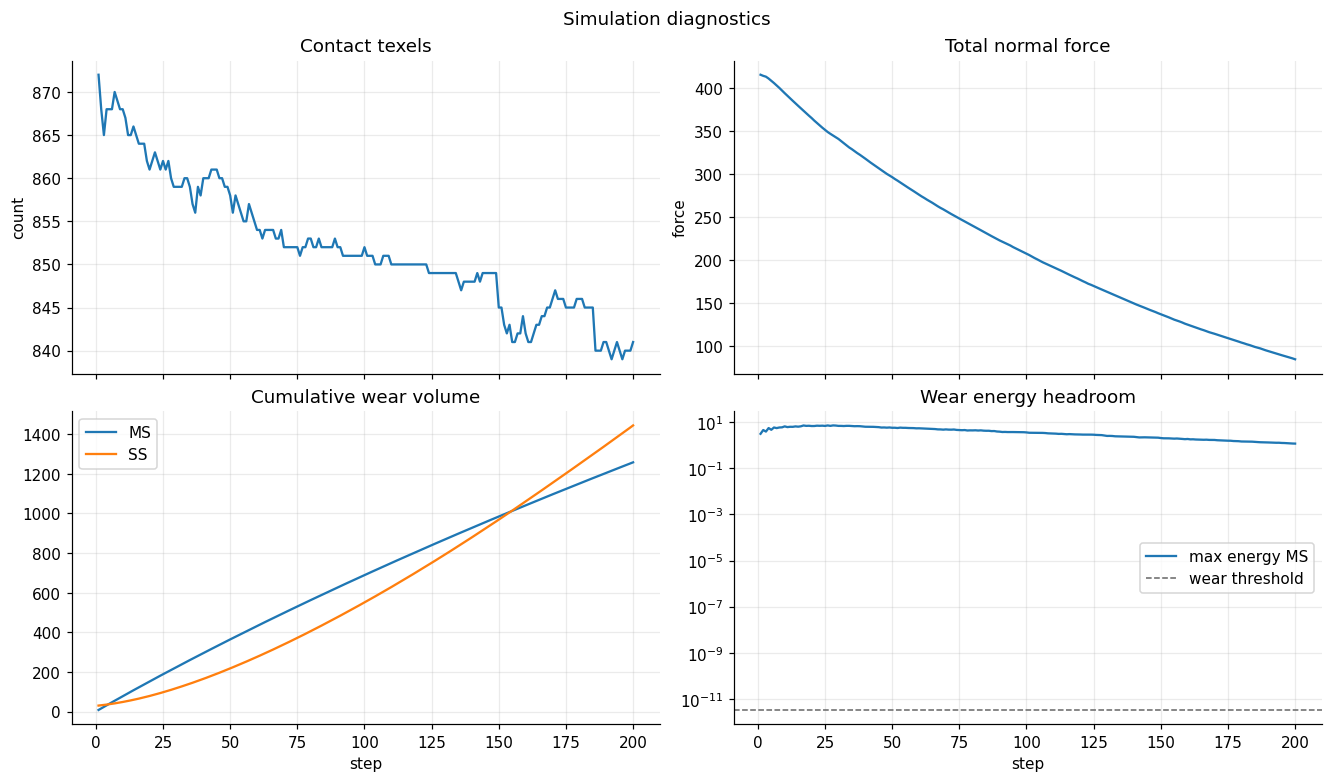

In [ ]:
def plot_diagnostics(log: pd.DataFrame, p: WearParameters):
    fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, constrained_layout=True)

    axes[0, 0].plot(log.index, log["contact_texels"])
    axes[0, 0].set_title("Contact texels")
    axes[0, 0].set_ylabel("count")

    axes[0, 1].plot(log.index, log["normal_force"])
    axes[0, 1].set_title("Total normal force")
    axes[0, 1].set_ylabel("force")

    axes[1, 0].plot(log.index, log["wear_volume_MS"].cumsum(), label="MS wear / step (cum)")
    axes[1, 0].plot(log.index, log["wear_volume_SS"].cumsum(), label="SS wear / step (cum)")
    axes[1, 0].plot(log.index, log["cumulative_wear_sum_MS"], "--", label="cum wear vol MS")
    axes[1, 0].plot(log.index, log["cumulative_wear_sum_SS"], "--", label="cum wear vol SS")
    axes[1, 0].set_title("Wear volumes")
    axes[1, 0].set_xlabel("step")
    axes[1, 0].legend(fontsize=8)

    axes[1, 1].plot(log.index, log["energy_max_MS"], label="max energy MS")
    axes[1, 1].axhline(p.deltaw, color="0.4", ls="--", lw=1, label="wear threshold")
    axes[1, 1].set_yscale("log")
    axes[1, 1].set_title("Wear energy headroom")
    axes[1, 1].set_xlabel("step")
    axes[1, 1].legend()

    fig.suptitle("Simulation diagnostics")
    plt.show()


plot_diagnostics(log, demo_params)


## 12. Cleaner evolution grid

The grid now focuses on the maps most useful for inspecting the run:

- height,
- contact mask,
- traction,
- cumulative wear map,
- cumulative sliding distance.


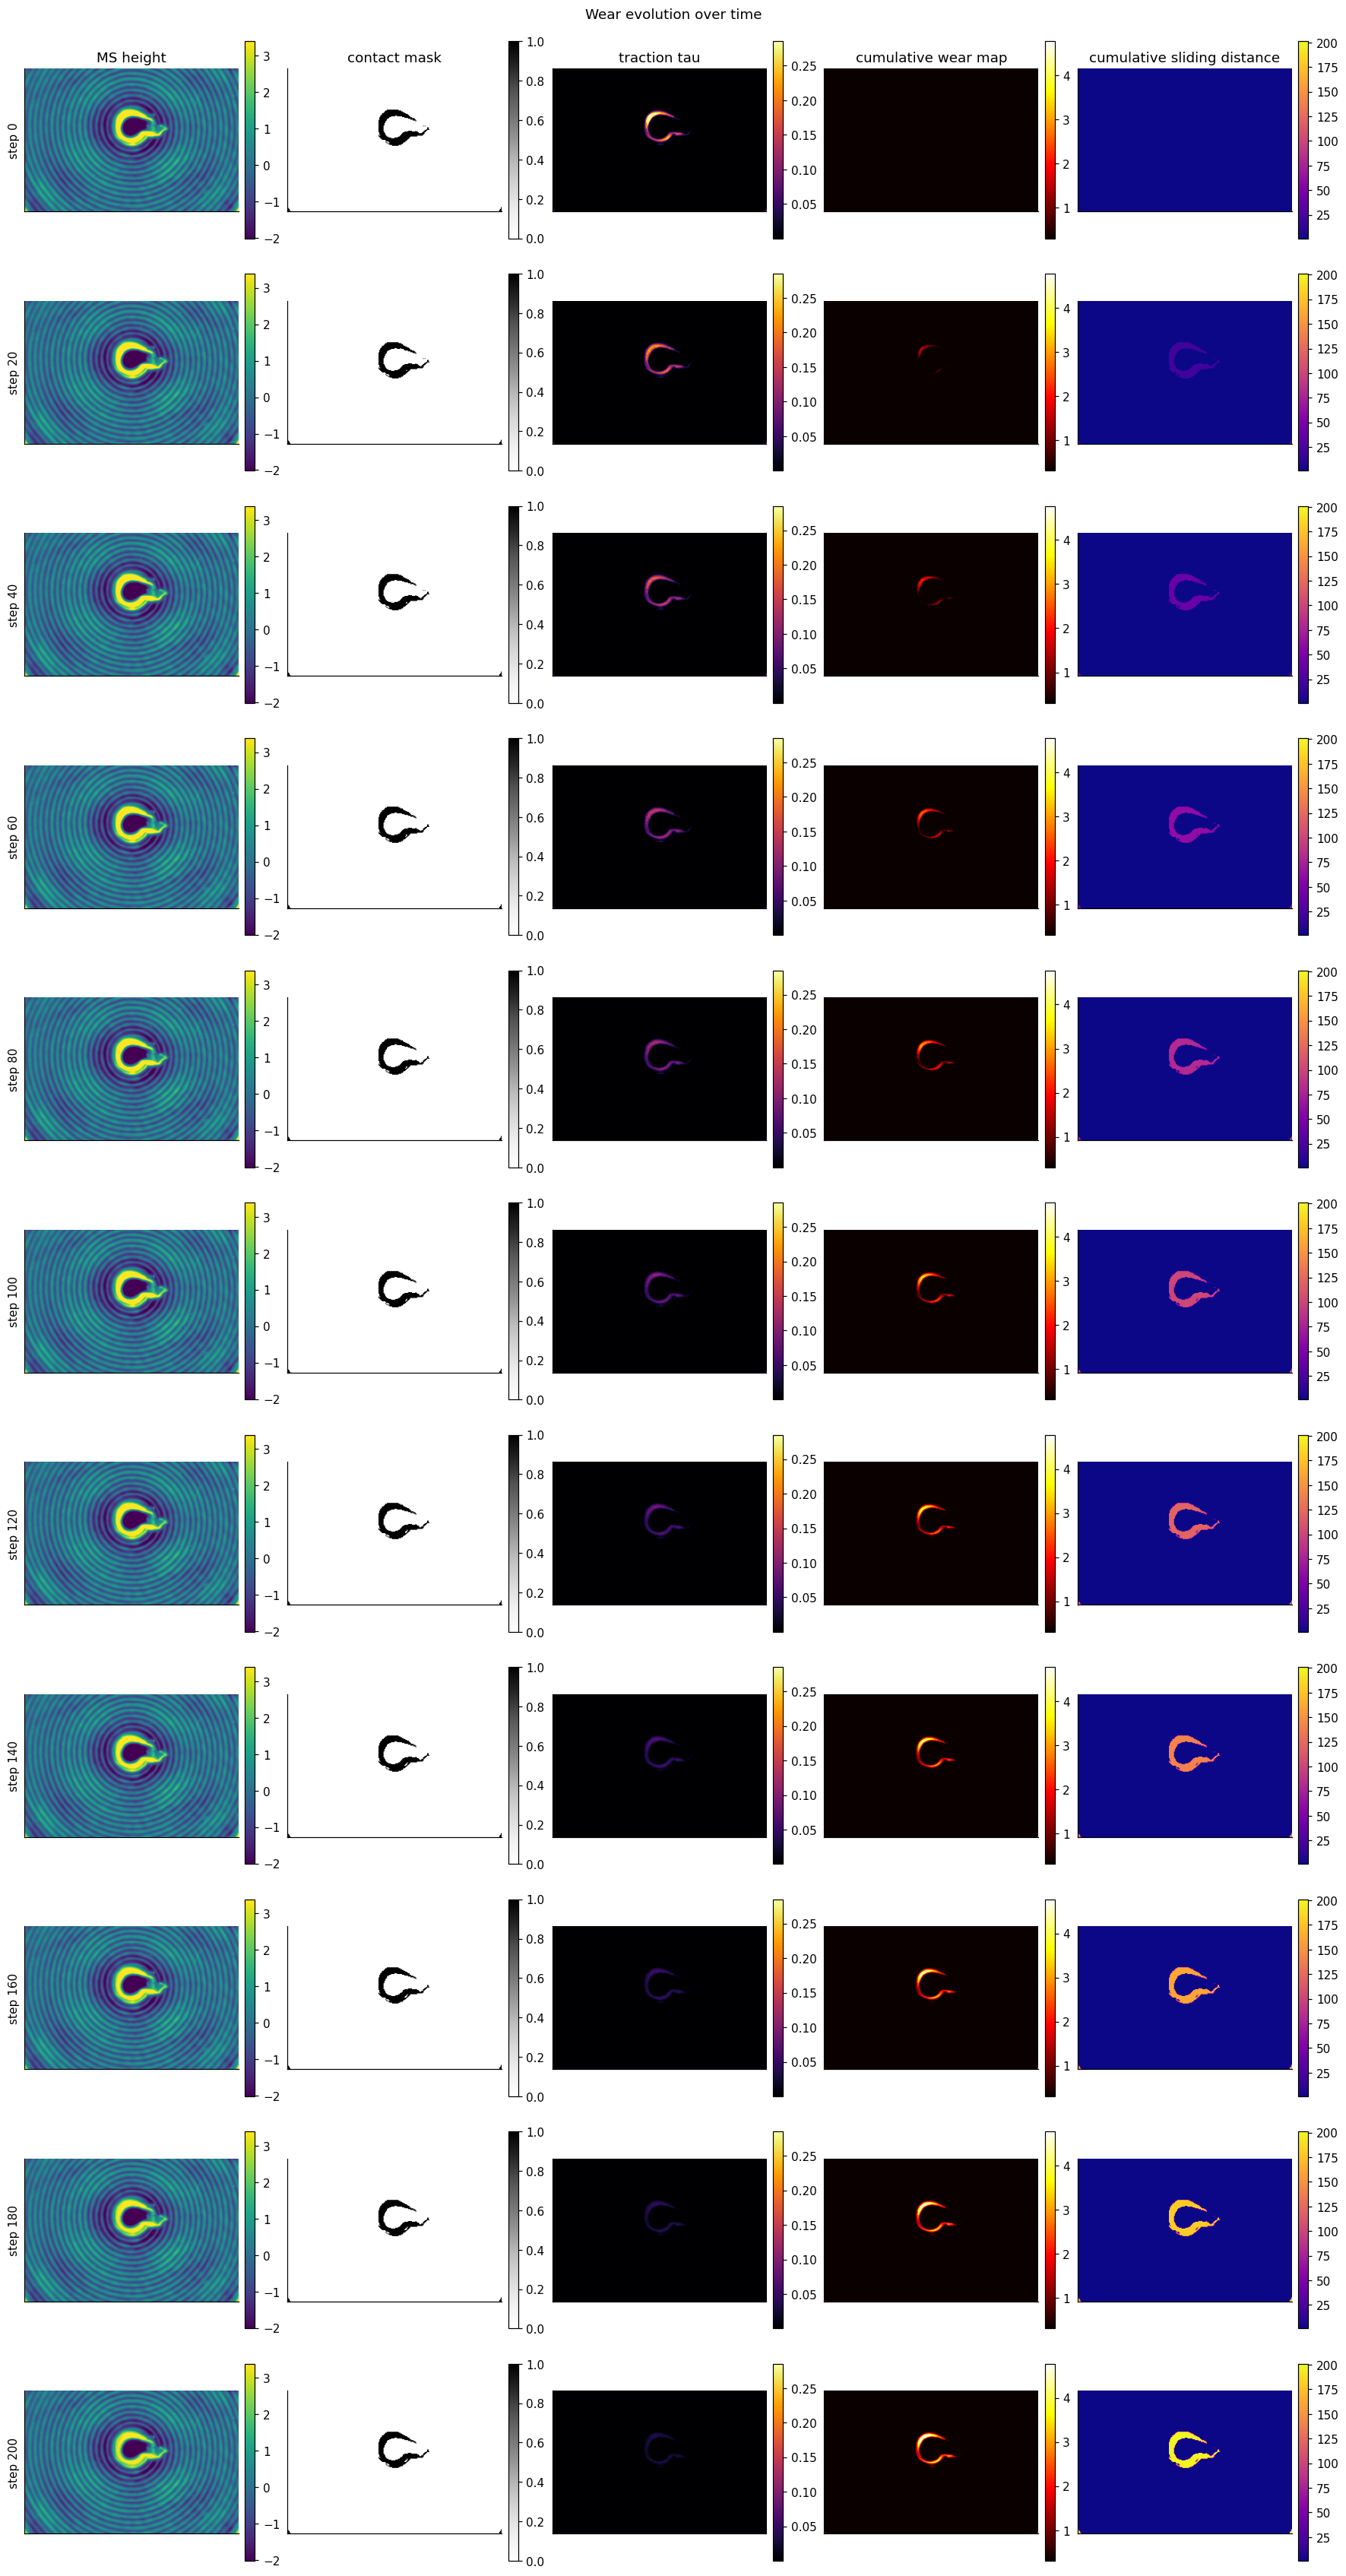

In [ ]:
def plot_evolution_grid(snapshots: Dict[int, dict]):
    steps = sorted(snapshots)
    fields = [
        ("MS", "MS height", "viridis"),
        ("SS", "SS height (flipped conv.)", "cividis"),
        ("mask", "contact mask", "Greys"),
        ("tau", "traction tau", "inferno"),
        ("wear_map", "cum. wear MS", "hot"),
        ("wear_map_SS", "cum. wear SS (body)", "hot"),
        ("sliding_distance", "cum. slip (lab grid)", "plasma"),
        ("sliding_distance_slave", "cum. slip (slave body)", "plasma"),
    ]

    limits: Dict[str, Tuple[float, float]] = {}
    for key, _, _ in fields:
        values = [snapshots[s][key] for s in steps]
        if key == "mask":
            limits[key] = (0.0, 1.0)
        elif key in {"tau", "wear_map", "wear_map_SS", "sliding_distance", "sliding_distance_slave"}:
            positive = [v[v > 0] for v in values if np.any(v > 0)]
            if positive:
                limits[key] = robust_limits(positive, q=(1, 99.5))
            else:
                limits[key] = (0.0, 1.0)
        else:
            limits[key] = robust_limits(values, q=(1, 99))

    fig, axes = plt.subplots(
        len(steps), len(fields),
        figsize=(2.4 * len(fields), 2.5 * len(steps)),
        constrained_layout=True,
    )
    if len(steps) == 1:
        axes = axes[None, :]

    for r, step_idx in enumerate(steps):
        for c, (key, label, cmap) in enumerate(fields):
            ax = axes[r, c]
            vmin, vmax = limits[key]
            im = ax.imshow(snapshots[step_idx][key], origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
            if r == 0:
                ax.set_title(label, fontsize=9)
            if c == 0:
                ax.set_ylabel(f"step {step_idx}")
            ax.set_xticks([])
            ax.set_yticks([])
            ax.grid(False)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    fig.suptitle("Wear evolution over time")
    plt.show()


plot_evolution_grid(snapshots)


## 13. Cross-section and removed material

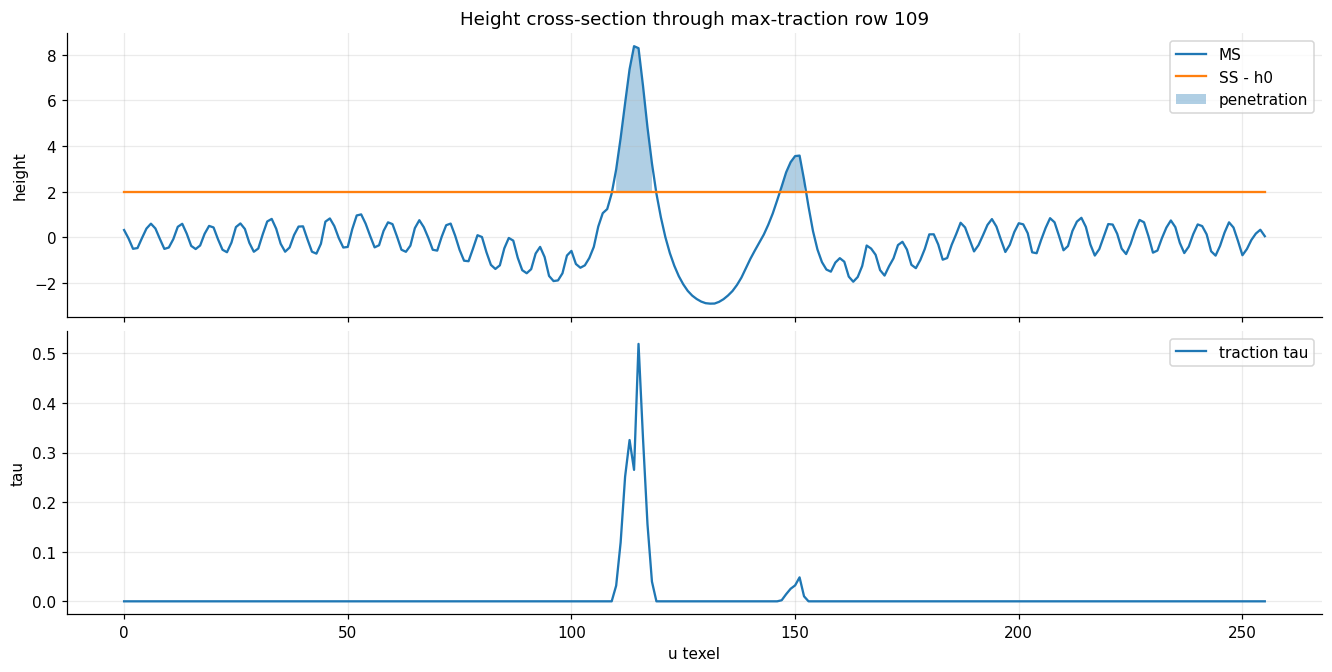

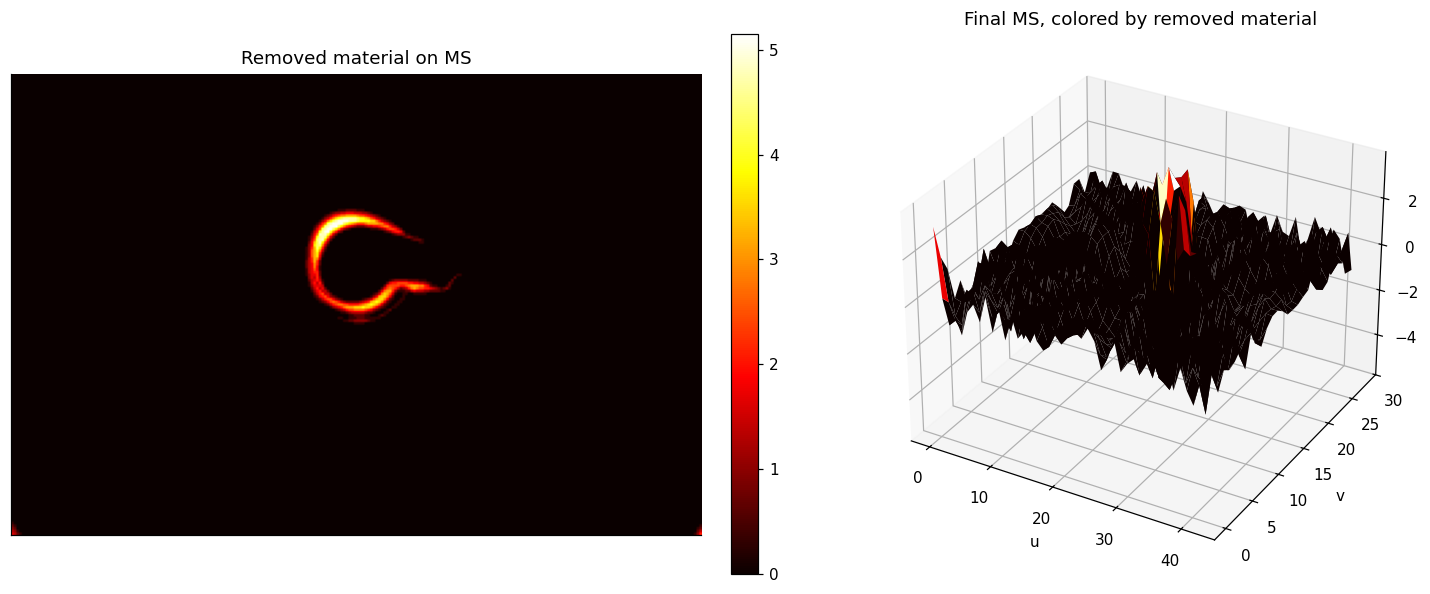

In [ ]:
def plot_contact_cross_section(MS: np.ndarray, SS: np.ndarray, contact: dict):
    row = int(np.unravel_index(np.argmax(contact["tau"]), contact["tau"].shape)[0])
    x = np.arange(MS.shape[1])
    upper = MS[row]
    lower = SS[row] - contact["h0"]

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, constrained_layout=True)
    axes[0].plot(x, upper, label="MS")
    axes[0].plot(x, lower, label="SS - h0")
    axes[0].fill_between(x, upper, lower, where=upper > lower, alpha=0.35, label="penetration")
    axes[0].set_title(f"Height cross-section through max-traction row {row}")
    axes[0].set_ylabel("height")
    axes[0].legend()

    axes[1].plot(x, contact["tau"][row], label="traction tau")
    axes[1].set_xlabel("u texel")
    axes[1].set_ylabel("tau")
    axes[1].legend()
    plt.show()


def plot_removed_material(MS_initial: np.ndarray, MS_final: np.ndarray):
    removed = np.maximum(MS_initial - MS_final, 0.0)
    fig = plt.figure(figsize=(14, 5.5))

    ax1 = fig.add_subplot(1, 2, 1)
    imshow_field(ax1, removed, "Removed material on MS", cmap="hot")

    ax2 = fig.add_subplot(1, 2, 2, projection="3d")
    stride = 6
    Z = MS_final[::stride, ::stride]
    Rm = removed[::stride, ::stride]
    y, x = np.mgrid[0:Z.shape[0], 0:Z.shape[1]]
    norm = colors.Normalize(vmin=float(Rm.min()), vmax=float(Rm.max()) if Rm.max() > 0 else 1.0)
    ax2.plot_surface(x, y, Z, facecolors=cm.hot(norm(Rm)), linewidth=0, antialiased=True, shade=False)
    ax2.set_title("Final MS, colored by removed material")
    ax2.set_xlabel("u")
    ax2.set_ylabel("v")
    ax2.set_zlabel("height")
    plt.tight_layout()
    plt.show()


plot_contact_cross_section(MS0, SS0, contact0)
plot_removed_material(MS0, final_state["MS"])

## 14. Surface metrics and texture direction

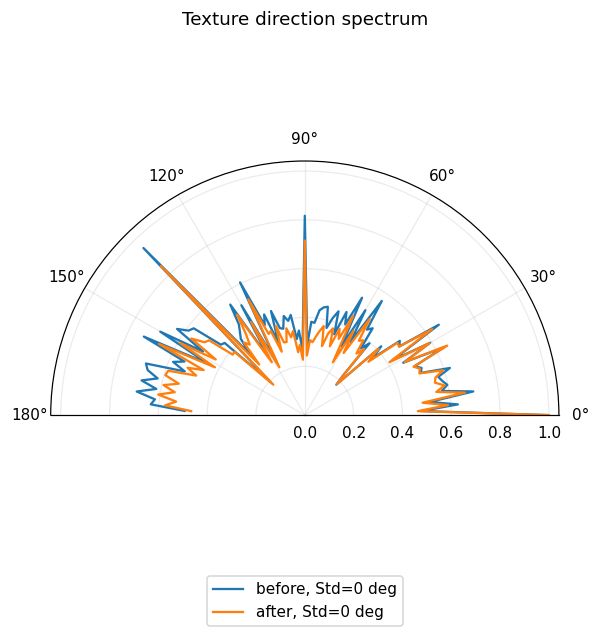

,MS before,MS after,delta
Sq,1.00000,0.85386,-0.14614
Sdq,0.48018,0.44616,-0.03402
Sdr,0.10201,0.09165,-0.01036
Ssk,1.83101,-0.37557,-2.20657
Sku,20.45459,10.21450,-10.24009
Spc,0.00000,0.00000,0.00000
Spd,0.02791,0.02858,0.00066
Std_deg,0.00000,0.00000,0.00000


In [ ]:
def texture_direction_spectrum(Z: np.ndarray, angular_step: int = 2) -> dict:
    F = np.fft.fftshift(np.fft.fft2(Z))
    mag = np.abs(F)
    rows, cols = Z.shape
    u = np.arange(cols) - cols // 2
    v = np.arange(rows) - rows // 2
    U, V = np.meshgrid(u, v)
    theta = np.mod(np.arctan2(V, U), np.pi)

    angles = np.arange(0, 180, angular_step)
    spectrum = np.zeros_like(angles, dtype=np.float64)
    half = np.deg2rad(angular_step / 2.0)
    for i, deg in enumerate(angles):
        a = np.deg2rad(deg)
        spectrum[i] = mag[np.abs(theta - a) <= half].sum()

    dominant = float(angles[int(np.argmax(spectrum))])
    return {"angles_deg": angles, "spectrum": spectrum, "Std_deg": dominant}


def surface_metrics(Z: np.ndarray) -> dict:
    Z = np.asarray(Z, dtype=np.float64)
    Zy, Zx = np.gradient(Z)
    Sq = float(np.sqrt(np.mean(Z**2)))
    Sdq = float(np.sqrt(np.mean(Zx**2 + Zy**2)))
    actual_area = float(np.sum(np.sqrt(1.0 + Zx[:-1, :-1]**2 + Zy[:-1, :-1]**2)))
    nominal_area = float((Z.shape[0] - 1) * (Z.shape[1] - 1))
    Sdr = (actual_area - nominal_area) / nominal_area
    Ssk = float(np.mean(Z**3) / (Sq**3)) if Sq > 0 else 0.0
    Sku = float(np.mean(Z**4) / (Sq**4)) if Sq > 0 else 0.0
    Spc = float(-0.5 * np.mean(ndimage.laplace(Z, mode="nearest")))
    local_max = ndimage.maximum_filter(Z, size=3, mode="nearest")
    peaks = (Z == local_max) & (Z > Z.mean())
    peaks[[0, -1], :] = False
    peaks[:, [0, -1]] = False
    Spd = float(peaks.sum() / Z.size)
    Std = texture_direction_spectrum(Z)["Std_deg"]
    return {"Sq": Sq, "Sdq": Sdq, "Sdr": Sdr, "Ssk": Ssk, "Sku": Sku, "Spc": Spc, "Spd": Spd, "Std_deg": Std}


def plot_texture_direction(before: np.ndarray, after: np.ndarray):
    spectra = [("before", texture_direction_spectrum(before)), ("after", texture_direction_spectrum(after))]
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="polar")
    ax.set_theta_zero_location("E")
    ax.set_thetamin(0)
    ax.set_thetamax(180)
    for label, sp in spectra:
        theta = np.deg2rad(sp["angles_deg"])
        y = sp["spectrum"] / max(sp["spectrum"].max(), 1e-12)
        ax.plot(theta, y, label=f"{label}, Std={sp['Std_deg']:.0f} deg")
    ax.set_title("Texture direction spectrum")
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.18))
    plt.show()


metrics = pd.DataFrame({
    "MS before": surface_metrics(MS0),
    "MS after": surface_metrics(final_state["MS"]),
})
metrics["delta"] = metrics["MS after"] - metrics["MS before"]
plot_texture_direction(MS0, final_state["MS"])
metrics.round(5)

## 14b. 3D normal-orientation changes on the unit sphere

The texture-direction plot above only shows the in-plane angular distribution. To make the change in
**surface-normal orientation** visible directly, we project per-pixel unit normals onto the unit
sphere and bin them with a cos(lat) area correction.

Three side-by-side 3D spheres are rendered:

- **before**: orientation density on the master surface before wear,
- **after**: orientation density on the master surface after the wear loop,
- **delta**: signed change `after - before`, with a red/blue diverging colormap so gained directions
  are red and lost directions are blue.


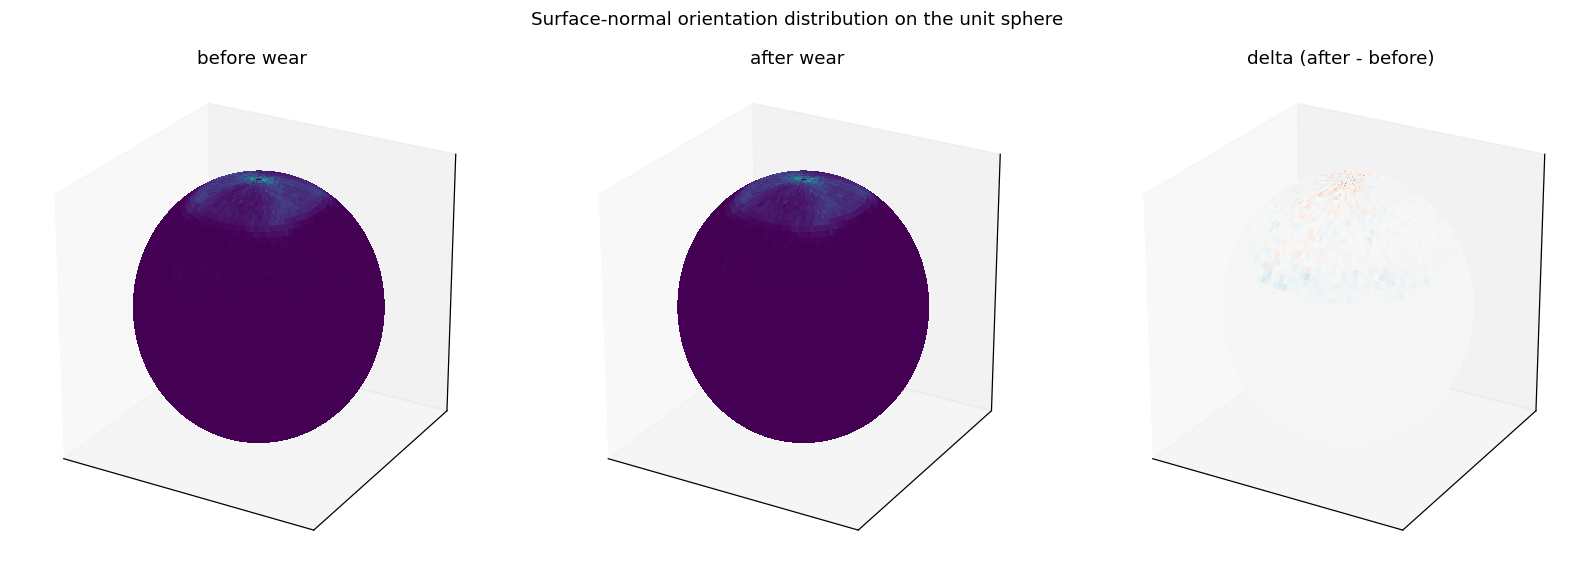

,MS before,MS after,delta
mean_resultant_length,0.91605,0.92097,0.00492
mean_normal_azim_deg,130.14500,127.60094,-2.54405
mean_normal_elev_deg,89.86747,89.88591,0.01845


In [ ]:
def surface_normals(Z: np.ndarray) -> np.ndarray:
    """Per-pixel unit surface normals from a height map.

    Uses central-difference gradients in pixel units; returns an (N, 3) array of points on the
    unit sphere with `n = (-Zx, -Zy, 1) / |...|`.
    """
    Zy, Zx = np.gradient(np.asarray(Z, dtype=np.float64))
    nx = -Zx
    ny = -Zy
    nz = np.ones_like(Zx)
    norm = np.sqrt(nx * nx + ny * ny + nz * nz)
    return np.stack([nx / norm, ny / norm, nz / norm], axis=-1).reshape(-1, 3)


def normal_density_on_sphere(normals: np.ndarray, n_lat: int = 64, n_lon: int = 128):
    """Bin unit normals on a (lat, lon) grid with cos(lat) area correction."""
    x, y, z = normals[:, 0], normals[:, 1], normals[:, 2]
    lat = np.arcsin(np.clip(z, -1.0, 1.0))
    lon = np.arctan2(y, x)
    lat_edges = np.linspace(-np.pi / 2, np.pi / 2, n_lat + 1)
    lon_edges = np.linspace(-np.pi, np.pi, n_lon + 1)
    H, _, _ = np.histogram2d(lat, lon, bins=[lat_edges, lon_edges])
    lat_centers = 0.5 * (lat_edges[:-1] + lat_edges[1:])
    lon_centers = 0.5 * (lon_edges[:-1] + lon_edges[1:])
    H = H / np.maximum(np.cos(lat_centers)[:, None], 1e-6)
    return lat_centers, lon_centers, H


def _sphere_xyz(lat_centers: np.ndarray, lon_centers: np.ndarray):
    Lon, Lat = np.meshgrid(lon_centers, lat_centers)
    x = np.cos(Lat) * np.cos(Lon)
    y = np.cos(Lat) * np.sin(Lon)
    z = np.sin(Lat)
    return x, y, z


def plot_normal_orientation_changes(before: np.ndarray, after: np.ndarray, n_lat: int = 64, n_lon: int = 128):
    """3D unit spheres of normal-direction density: before, after, and delta — oblique and top (+z) views."""
    n_before = surface_normals(before)
    n_after = surface_normals(after)

    lat_c, lon_c, H_before = normal_density_on_sphere(n_before, n_lat, n_lon)
    _, _, H_after = normal_density_on_sphere(n_after, n_lat, n_lon)
    H_before = H_before / max(H_before.sum(), 1e-12)
    H_after = H_after / max(H_after.sum(), 1e-12)
    H_delta = H_after - H_before

    x, y, z = _sphere_xyz(lat_c, lon_c)
    common_max = max(H_before.max(), H_after.max(), 1e-12)
    delta_lim = max(abs(H_delta.min()), abs(H_delta.max()), 1e-12)

    panels = [
        (H_before / common_max, "before wear", "before (top view)", "viridis", colors.Normalize(0.0, 1.0)),
        (H_after / common_max, "after wear", "after (top view)", "viridis", colors.Normalize(0.0, 1.0)),
        (H_delta, "delta (after - before)", "delta (top view)", "RdBu_r", colors.Normalize(-delta_lim, delta_lim)),
    ]

    # Row 0: oblique; row 1: look straight down +z (north pole centered).
    view_rows = ((25, -60), (90, -90))

    fig = plt.figure(figsize=(15, 10))
    for row, (elev, azim) in enumerate(view_rows):
        for col, (data, title_oblique, title_top, cmap_name, norm) in enumerate(panels):
            ax = fig.add_subplot(2, 3, row * 3 + col + 1, projection="3d")
            cmap = plt.get_cmap(cmap_name)
            ax.plot_surface(
                x, y, z,
                facecolors=cmap(norm(data)),
                rstride=1, cstride=1, linewidth=0, antialiased=False, shade=False,
            )
            ax.set_title(title_oblique if row == 0 else title_top)
            ax.set_box_aspect((1, 1, 1))
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_zticks([])
            ax.view_init(elev=elev, azim=azim)

    fig.suptitle("Surface-normal orientation distribution on the unit sphere", y=0.98)
    plt.tight_layout()
    plt.show()


# Compute a quick scalar summary alongside the figure: how concentrated is the orientation
# distribution before vs after, and where did the dominant direction move?
def normal_orientation_summary(Z: np.ndarray) -> dict:
    n = surface_normals(Z)
    mean = n.mean(axis=0)
    mean_len = float(np.linalg.norm(mean))
    mean = mean / max(mean_len, 1e-12)
    azim = float(np.degrees(np.arctan2(mean[1], mean[0])))
    elev = float(np.degrees(np.arcsin(mean[2])))
    return {
        "mean_resultant_length": mean_len,
        "mean_normal_azim_deg": azim,
        "mean_normal_elev_deg": elev,
    }


orientation_table = pd.DataFrame({
    "MS before": normal_orientation_summary(MS0),
    "MS after": normal_orientation_summary(final_state["MS"]),
})
orientation_table["delta"] = orientation_table["MS after"] - orientation_table["MS before"]

plot_normal_orientation_changes(MS0, final_state["MS"])
orientation_table.round(5)


## 15. Compare several surface pairs

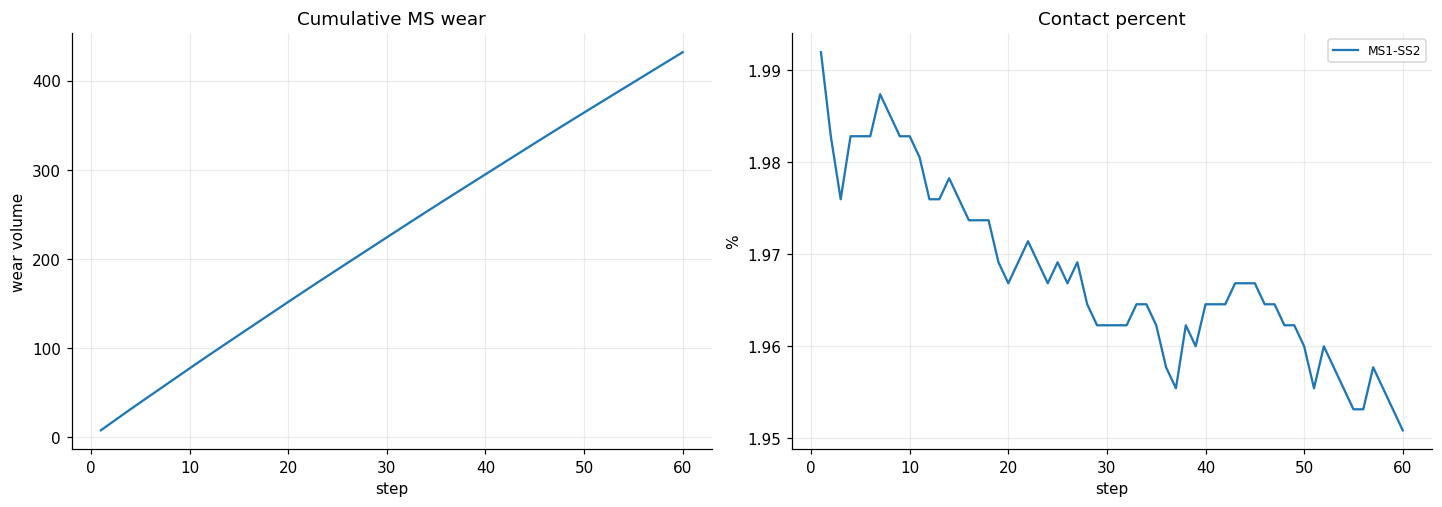

,final_contact_percent,cumulative_wear_MS,cumulative_wear_SS,mean_force
pair,,,,
MS1-SS2,1.95084,431.75519,275.97565,342.26233


In [ ]:
def compare_surface_pairs(surfaces: Dict[int, np.ndarray], pairs: List[Tuple[int, int]], p: WearParameters, direction: int, n_steps: int = 60):
    rows = []
    histories = {}
    for ms_i, ss_i in pairs:
        MS_i, SS_i = select_pair(surfaces, ms_i, ss_i)
        _, log_i, _ = run_simulation(MS_i, SS_i, p, direction=direction, n_steps=n_steps, load_controlled=False, save_every=0)
        label = f"MS{ms_i}-SS{ss_i}"
        histories[label] = log_i
        rows.append({
            "pair": label,
            "final_contact_percent": float(log_i["contact_percent"].iloc[-1]),
            "cumulative_wear_MS": float(log_i["cumulative_wear_sum_MS"].iloc[-1]),
            "cumulative_wear_SS": float(log_i["cumulative_wear_sum_SS"].iloc[-1]),
            "mean_force": float(log_i["normal_force"].mean()),
        })
    return pd.DataFrame(rows).set_index("pair"), histories


surface_keys = sorted(surfaces.keys())
def _valid_pairs(keys):
    preferred = [(1, 2), (3, 4), (5, 6), (1, 3), (2, 4), (5, 1)]
    valid = [pair for pair in preferred if pair[0] in keys and pair[1] in keys]
    if valid:
        return valid
    if len(keys) >= 2:
        return [(keys[0], keys[1])]
    raise ValueError("Need at least 2 surfaces for pair comparison")

pairs = _valid_pairs(surface_keys)
pair_table, pair_histories = compare_surface_pairs(surfaces, pairs, demo_params, SLIDE_DIR, n_steps=60)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
for label, hist in pair_histories.items():
    axes[0].plot(hist.index, hist["cumulative_wear_sum_MS"], label=f"{label} MS")
    axes[0].plot(hist.index, hist["cumulative_wear_sum_SS"], "--", label=f"{label} SS")
    axes[1].plot(hist.index, hist["contact_percent"], label=label)
axes[0].set_title("Cumulative wear volume (MS solid, SS dashed)")
axes[0].set_xlabel("step")
axes[0].set_ylabel("sum of cum. wear map")
axes[0].legend(fontsize=7, ncol=2)
axes[1].set_title("Contact percent")
axes[1].set_xlabel("step")
axes[1].set_ylabel("%")
axes[1].legend(fontsize=8, ncol=2)
plt.show()

pair_table.round(5)


## 16. Cleaner GIF with cumulative wear and sliding maps

The animation now shows:

- MS height,
- contact mask,
- cumulative wear map,
- cumulative sliding distance map.

This keeps the GIF focused on accumulated quantities and avoids per-step noise from a single
wear increment.


Saved wear_evolution.gif


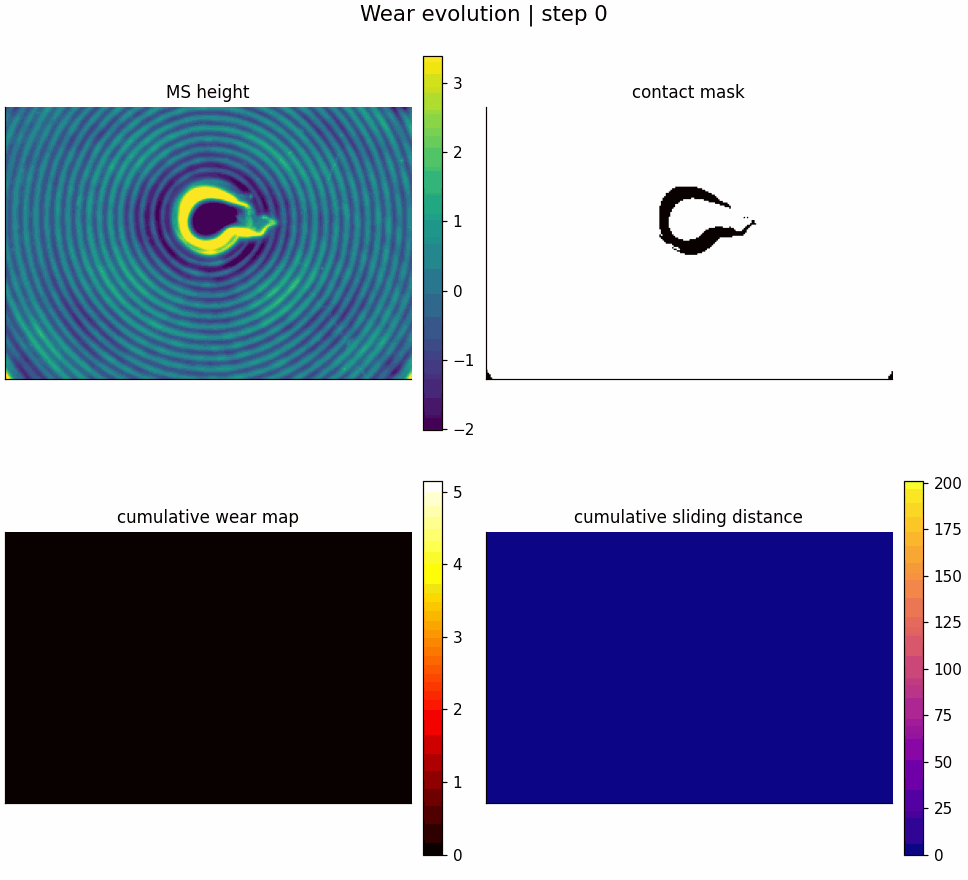

In [ ]:
def make_animation(snapshots: Dict[int, dict], out_path: str = "wear_evolution.gif", fps: int = 3):
    steps = sorted(snapshots)

    ms_vmin, ms_vmax = robust_limits([snapshots[s]["MS"] for s in steps], q=(1, 99))
    ss_vmin, ss_vmax = robust_limits([snapshots[s]["SS"] for s in steps], q=(1, 99))
    wear_ms = [snapshots[s]["wear_map"] for s in steps if np.any(snapshots[s]["wear_map"] > 0)]
    wear_ss = [snapshots[s]["wear_map_SS"] for s in steps if np.any(snapshots[s]["wear_map_SS"] > 0)]
    slide_ss = [snapshots[s]["sliding_distance_slave"] for s in steps if np.any(snapshots[s]["sliding_distance_slave"] > 0)]

    wear_ms_lim = (0.0, max(float(v.max()) for v in wear_ms)) if wear_ms else (0.0, 1.0)
    wear_ss_lim = (0.0, max(float(v.max()) for v in wear_ss)) if wear_ss else (0.0, 1.0)
    slide_ss_lim = (0.0, max(float(v.max()) for v in slide_ss)) if slide_ss else (0.0, 1.0)

    fig, axes = plt.subplots(2, 3, figsize=(11.0, 7.2), constrained_layout=True)
    axes = axes.ravel()

    im0 = axes[0].imshow(snapshots[steps[0]]["MS"], origin="lower", vmin=ms_vmin, vmax=ms_vmax, cmap="viridis")
    im1 = axes[1].imshow(snapshots[steps[0]]["SS"], origin="lower", vmin=ss_vmin, vmax=ss_vmax, cmap="cividis")
    im2 = axes[2].imshow(snapshots[steps[0]]["mask"], origin="lower", vmin=0, vmax=1, cmap="Greys")
    im3 = axes[3].imshow(snapshots[steps[0]]["wear_map"], origin="lower", vmin=wear_ms_lim[0], vmax=wear_ms_lim[1], cmap="hot")
    im4 = axes[4].imshow(snapshots[steps[0]]["wear_map_SS"], origin="lower", vmin=wear_ss_lim[0], vmax=wear_ss_lim[1], cmap="hot")
    im5 = axes[5].imshow(snapshots[steps[0]]["sliding_distance_slave"], origin="lower", vmin=slide_ss_lim[0], vmax=slide_ss_lim[1], cmap="plasma")

    titles = [
        "MS height",
        "SS height",
        "contact mask",
        "cum. wear MS",
        "cum. wear SS (body)",
        "cum. slip slave body",
    ]
    for ax, title in zip(axes, titles):
        ax.set_title(title, fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(False)

    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.03)
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.03)
    fig.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.03)
    fig.colorbar(im4, ax=axes[4], fraction=0.046, pad=0.03)
    fig.colorbar(im5, ax=axes[5], fraction=0.046, pad=0.03)

    suptitle = fig.suptitle(f"Wear evolution | step {steps[0]}", fontsize=14)

    def update(i):
        s = steps[i]
        im0.set_data(snapshots[s]["MS"])
        im1.set_data(snapshots[s]["SS"])
        im2.set_data(snapshots[s]["mask"])
        im3.set_data(snapshots[s]["wear_map"])
        im4.set_data(snapshots[s]["wear_map_SS"])
        im5.set_data(snapshots[s]["sliding_distance_slave"])
        suptitle.set_text(f"Wear evolution | step {s}")
        return im0, im1, im2, im3, im4, im5, suptitle

    anim = FuncAnimation(fig, update, frames=len(steps), interval=1000 / fps, blit=False)
    anim.save(out_path, writer=PillowWriter(fps=fps))
    plt.close(fig)
    return out_path


WEAR_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
gif_path = make_animation(snapshots, str(WEAR_RESULTS_DIR / "wear_evolution.gif"))
print("Saved", gif_path)

from IPython.display import Image, display
try:
    display(Image(filename=gif_path))
except Exception as exc:
    print("Animation saved but could not embed:", exc)


## 17. Export results

In [ ]:
WEAR_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
out_dir = WEAR_RESULTS_DIR

log.to_csv(out_dir / "simulation_log.csv")
metrics.to_csv(out_dir / "surface_metrics_before_after.csv")
pair_table.to_csv(out_dir / "surface_pair_comparison.csv")
if truemap_metadata:
    import json as _json

    _meta_out = {
        k: (v if isinstance(v, (str, int, float, bool)) else str(v))
        for k, v in truemap_metadata.items()
    }
    (out_dir / "truemap_metadata.json").write_text(
        _json.dumps(_meta_out, indent=2), encoding="utf-8"
    )

np.savez_compressed(
    out_dir / "final_state.npz",
    MS_initial=MS0,
    SS_initial=SS0,
    MS_final=final_state["MS"],
    SS_final=final_state["SS"],
    removed_material=np.maximum(MS0 - final_state["MS"], 0.0),
    cumulative_wear_MS=final_state["cumulative_wear_MS"],
    cumulative_wear_SS=final_state["cumulative_wear_SS"],
    current_wear_increment_MS=final_state["last_wear_MS"],
    current_wear_increment_SS=final_state["last_wear_SS"],
    sliding_distance=final_state["sliding_distance"],
    sliding_distance_slave=final_state["sliding_distance_slave"],
)

np.savez_compressed(
    out_dir / "snapshots.npz",
    **{f"step_{s}_{name}": value for s, snap in snapshots.items() for name, value in snap.items()}
)

# Canonical TrueMapData export with Surface_simulation_1..5
canonical_metadata = {
    **{k: (v if isinstance(v, (str, int, float, bool)) else str(v)) for k, v in truemap_metadata.items()},
    "slide_dir": int(SLIDE_DIR),
    "n_steps": int(N_STEPS),
    "save_every": int(SAVE_EVERY),
    "hardness_master": float(HARDNESS_MASTER),
    "hardness_slave": float(HARDNESS_SLAVE),
}

canonical_path = out_dir / "final_state_surfaces.mat"
MATExporter().export(
    {
        "surfaces": {
            1: MS0,
            2: SS0,
            3: final_state["MS"],
            4: final_state["SS"],
            5: final_state["cumulative_wear_MS"],
        },
        "parameters": {
            1: surface_metrics(MS0),
            3: surface_metrics(final_state["MS"]),
        },
        "metadata": canonical_metadata,
    },
    str(canonical_path),
)

for path in sorted(out_dir.iterdir()):
    print(f"{path}: {path.stat().st_size / 1024:.1f} KB")


def upsample_height_map(Z: np.ndarray, detail_factor: int = 2, order: int = 3) -> np.ndarray:
    if detail_factor <= 1:
        return Z.astype(np.float64, copy=True)
    return ndimage.zoom(Z.astype(np.float64), zoom=detail_factor, order=order)


def export_heightmap_obj(Z: np.ndarray, out_path: Path, xy_scale: float = 1.0, z_scale: float = 1.0) -> Path:
    Z = np.asarray(Z, dtype=np.float64)
    h, w = Z.shape
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    with out_path.open("w", encoding="utf-8") as f:
        f.write("# Heightmap OBJ export (grid triangulation)\n")

        for y in range(h):
            for x in range(w):
                f.write(f"v {x * xy_scale:.6f} {y * xy_scale:.6f} {Z[y, x] * z_scale:.6f}\n")

        def vid(y0: int, x0: int) -> int:
            return y0 * w + x0 + 1

        for y in range(h - 1):
            for x in range(w - 1):
                v00 = vid(y, x)
                v10 = vid(y, x + 1)
                v01 = vid(y + 1, x)
                v11 = vid(y + 1, x + 1)
                f.write(f"f {v00} {v10} {v11}\n")
                f.write(f"f {v00} {v11} {v01}\n")

    return out_path


detail_factor = 3
MS_final_hi = upsample_height_map(final_state["MS"], detail_factor=detail_factor, order=3)
model_obj_path = export_heightmap_obj(
    MS_final_hi,
    out_dir / f"MS_final_high_detail_x{detail_factor}.obj",
    xy_scale=1.0 / detail_factor,
    z_scale=1.0,
)

print("Saved", canonical_path)
print("Saved", model_obj_path)


wear_results\final_state.npz: 678.6 KB
wear_results\final_state_surfaces.mat: 666.8 KB
wear_results\MS_final_high_detail_x3.obj: 30632.4 KB
wear_results\simulation_log.csv: 53.2 KB
wear_results\snapshots.npz: 3948.7 KB
wear_results\surface_metrics_before_after.csv: 0.5 KB
wear_results\surface_pair_comparison.csv: 0.2 KB
wear_results\truemap_metadata.json: 0.4 KB


Saved wear_results\final_state_surfaces.mat
Saved wear_results\MS_final_high_detail_x3.obj


## 18. Mapping to your GPU texture-space wear project

| Notebook block | Your GPU pipeline equivalent |
|---|---|
| `Surface_simulation_i` | UV atlas tile, height map, normal map, roughness or wear texture |
| `contact_at_h0` | contact projection, overlap mask, micro-contact mask |
| `combined_mu` | per-pixel anisotropic or asymmetric friction coefficient |
| `tau = mu * deltaF` | traction map in the tangential contact frame |
| `combined_wear_energy` | local dissipated energy, `tau * |v_t| * dt` |
| `apply_wear` | compute shader accumulation into the wear or height atlas |
| `slide_slave` | sampling the opposite object's UVs using the slip direction field |
| `sliding_distance` | the direction and distance accumulation map you can debug in your shader |
| `texture_direction_spectrum` | validation metric for groove direction against GelSight scans |

The important fix for your simulator is the same as the notebook fix: do not let one frame write unbounded wear. Keep explicit counters or diagnostics for rejected writes, clamp wear depth per texel, and accumulate sliding distance separately from the wear write.

## 19. Derive `derived_surfaces.mat` (TrueMap `MATExporter`)

After surfaces are loaded (`MS`, `SS` pair), persist **physical-scale-ready** arrays the same way
`MATExporter` does elsewhere: keys `Surface_simulation_i`, optional `SurfaceParameters_i`, plus `metadata`
(`mmpp`, `x_length`, `y_length` when present on the source TMD).

The cell below writes `notebooks/derived_surfaces.mat` and reloads it to verify the round-trip.


In [ ]:
def _non_empty_parameters(params: dict) -> dict:
    """MATExporter skips empty parameter structs; filter accordingly."""
    return {k: v for k, v in params.items() if isinstance(v, dict) and v}


out_path = DERIVED_SURFACES_MAT
MS_now, SS_now = select_pair(surfaces, MS_IDX, SS_IDX)

export_payload = {
    "surfaces": {1: MS_now, 2: -SS_now},
    "parameters": _non_empty_parameters(dict(stored_surface_params)),
    "metadata": {
        **{k: (v if isinstance(v, (str, int, float, bool)) else str(v)) for k, v in truemap_metadata.items()},
        "slide_dir": int(SLIDE_DIR),
        "export_note": "notebook_derived_surfaces",
    },
}

MATExporter().export(export_payload, str(out_path))
print(f"Wrote {out_path.resolve()}")

_roundtrip = MATImporter().load(str(out_path))
assert "surfaces" in _roundtrip and len(_roundtrip["surfaces"]) >= 1
print("Round-trip OK: surface keys", sorted(_roundtrip["surfaces"].keys()))
if _roundtrip.get("metadata"):
    print("metadata keys:", sorted(_roundtrip["metadata"].keys()))


Wrote E:\TrueMapData\notebooks\derived_surfaces.mat
